In [1]:
# Install Prophet if not already installed
# !pip install prophet

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
file_path = "/content/Electric_Consumption_And_Cost_(2010_-_Sep_2025)_20260330.csv"

df = pd.read_csv(file_path, engine='python', on_bad_lines='warn')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (553666, 27)

Columns:
['Development Name', 'Borough', 'Account Name', 'Location', 'Meter AMR', 'Meter Scope', 'TDS #', 'EDP', 'RC Code', 'Funding Source', 'AMP #', 'Vendor Name', 'UMIS BILL ID', 'Revenue Month', 'Service Start Date', 'Service End Date', '# days', 'Meter Number', 'Estimated', 'Current Charges', 'Rate Class', 'Bill Analyzed', 'Consumption (KWH)', 'KWH Charges', 'Consumption (KW)', 'KW Charges', 'Other charges']

First 5 rows:


,Development Name,Borough,Account Name,Location,Meter AMR,Meter Scope,TDS #,EDP,RC Code,Funding Source,AMP #,Vendor Name,UMIS BILL ID,Revenue Month,Service Start Date,Service End Date,# days,Meter Number,Estimated,Current Charges,Rate Class,Bill Analyzed,Consumption (KWH),KWH Charges,Consumption (KW),KW Charges,Other charges
0,WOODSIDE,QUEENS,WOODSIDE,BLD 06,INTERVAL,NaN,33.0,316,Q003300,FEDERAL,NY005000330P,NEW YORK POWER AUTHORITY,15921783,2025-09,08/21/2025,09/22/2025,32.0,1783947,N,$930.43,GOV/NYC/068,Yes,0,$0,71.32,$930.43,$0
1,WOODSIDE,QUEENS,WOODSIDE,BLD 10,INTERVAL,NaN,33.0,316,Q003300,FEDERAL,NY005000330P,NEW YORK POWER AUTHORITY,15921783,2025-09,08/21/2025,09/22/2025,32.0,1788883,N,"$1,020.7",GOV/NYC/068,Yes,0,$0,78.24,"$1,020.7",$0
2,WOODSIDE,QUEENS,WOODSIDE,BLD 03,AMR,NaN,33.0,316,Q003300,FEDERAL,NY005000330P,NEW YORK POWER AUTHORITY,15921783,2025-09,08/21/2025,09/22/2025,32.0,2788885,N,"$8,443.46",GOV/NYC/068,Yes,"38,207","$1,768.6",0,$0,"$6,674.86"
3,WOODSIDE,QUEENS,WOODSIDE,BLD 09,AMR,NaN,33.0,316,Q003300,FEDERAL,NY005000330P,NEW YORK POWER AUTHORITY,15921783,2025-09,08/21/2025,09/22/2025,32.0,2783922,N,"$7,319.27",GOV/NYC/068,Yes,"33,120","$1,533.12",0,$0,"$5,786.15"
4,WOODSIDE,QUEENS,WOODSIDE,BLD 04,INTERVAL,NaN,33.0,316,Q003300,FEDERAL,NY005000330P,NEW YORK POWER AUTHORITY,15921783,2025-09,08/21/2025,09/22/2025,32.0,1783950,N,$933.56,GOV/NYC/068,Yes,0,$0,71.56,$933.56,$0


In [3]:
# Copy dataframe
df_clean = df.copy()

# Convert date columns
df_clean["Service Start Date"] = pd.to_datetime(df_clean["Service Start Date"], errors="coerce")
df_clean["Service End Date"] = pd.to_datetime(df_clean["Service End Date"], errors="coerce")

# Clean KWH column (remove commas, dollar signs, spaces and convert to float)
df_clean["Consumption (KWH)"] = (
    df_clean["Consumption (KWH)"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)
df_clean["Consumption (KWH)"] = pd.to_numeric(df_clean["Consumption (KWH)"], errors="coerce")

# Drop rows with missing values in key columns
df_clean = df_clean.dropna(subset=["Consumption (KWH)", "Service Start Date", "Service End Date", "Borough"])

# Use the existing '# days' column if available, otherwise calculate
df_clean["days"] = (df_clean["Service End Date"] - df_clean["Service Start Date"]).dt.days

# Remove invalid rows (zero or negative days, zero or negative consumption)
df_clean = df_clean[df_clean["days"] > 0]
df_clean = df_clean[df_clean["Consumption (KWH)"] > 0]

# Calculate daily consumption per row
df_clean["daily_kwh"] = df_clean["Consumption (KWH)"] / df_clean["days"]

print("Cleaned dataset shape:", df_clean.shape)
print("\nBorough counts:")
print(df_clean["Borough"].value_counts())

print("\nSample:")
display(df_clean[["Service Start Date", "Service End Date", "Consumption (KWH)", "days", "daily_kwh", "Borough"]].head())

Cleaned dataset shape: (362215, 29)

Borough counts:
Borough
BROOKLYN                    140819
MANHATTAN                    93128
BRONX                        83216
QUEENS                       37526
STATEN ISLAND                 2995
NON DEVELOPMENT FACILITY      2579
FHA                           1952
Name: count, dtype: int64

Sample:


,Service Start Date,Service End Date,Consumption (KWH),days,daily_kwh,Borough
2,2025-08-21,2025-09-22,38207.0,32,1193.96875,QUEENS
3,2025-08-21,2025-09-22,33120.0,32,1035.00000,QUEENS
5,2025-08-21,2025-09-22,23326.0,32,728.93750,QUEENS
7,2025-08-21,2025-09-22,36994.0,32,1156.06250,QUEENS
8,2025-08-21,2025-09-22,30661.0,32,958.15625,QUEENS


In [4]:
# Keep only the 5 real NYC boroughs
valid_boroughs = ["BROOKLYN", "MANHATTAN", "BRONX", "QUEENS", "STATEN ISLAND"]
df_clean = df_clean[df_clean["Borough"].isin(valid_boroughs)].copy()

print("Shape after borough filter:", df_clean.shape)
print("\nBorough counts:")
print(df_clean["Borough"].value_counts())

# Expand each billing row into individual daily records
print("\nExpanding rows into daily records (this may take a minute)...")

expanded_rows = []

for _, row in df_clean.iterrows():
    date_range = pd.date_range(
        start=row["Service Start Date"],
        end=row["Service End Date"] - pd.Timedelta(days=1)
    )
    for single_date in date_range:
        expanded_rows.append({
            "ds": single_date,
            "y": row["daily_kwh"],
            "Borough": row["Borough"]
        })

daily_df = pd.DataFrame(expanded_rows)

print("Expanded daily dataset shape:", daily_df.shape)
display(daily_df.head())

Shape after borough filter: (357684, 29)

Borough counts:
Borough
BROOKLYN         140819
MANHATTAN         93128
BRONX             83216
QUEENS            37526
STATEN ISLAND      2995
Name: count, dtype: int64

Expanding rows into daily records (this may take a minute)...
Expanded daily dataset shape: (10860703, 3)


,ds,y,Borough
0,2025-08-21,1193.96875,QUEENS
1,2025-08-22,1193.96875,QUEENS
2,2025-08-23,1193.96875,QUEENS
3,2025-08-24,1193.96875,QUEENS
4,2025-08-25,1193.96875,QUEENS


In [5]:
# Aggregate total consumption per day (all boroughs combined)
daily_agg = daily_df.groupby("ds").agg({"y": "sum"}).reset_index()
daily_agg = daily_agg.sort_values("ds").reset_index(drop=True)

# Create Monthly Mean (resample daily into monthly average)
monthly_df = daily_agg.set_index("ds").resample("MS").mean().reset_index()

# Create Yearly Mean (resample daily into yearly average)
yearly_df = daily_agg.set_index("ds").resample("YS").mean().reset_index()

print("Daily shape:", daily_agg.shape)
print("Monthly shape:", monthly_df.shape)
print("Yearly shape:", yearly_df.shape)

print("\nDaily sample (first 5 rows):")
display(daily_agg.head())

print("\nMonthly sample (first 5 rows):")
display(monthly_df.head())

print("\nYearly sample (first 5 rows):")
display(yearly_df.head())

print("\nDate range:")
print("From:", daily_agg["ds"].min())
print("To:  ", daily_agg["ds"].max())

Daily shape: (5095, 2)
Monthly shape: (191, 2)
Yearly shape: (17, 2)

Daily sample (first 5 rows):


,ds,y
0,2009-12-17,0.970588
1,2009-12-18,0.970588
2,2009-12-19,0.970588
3,2009-12-20,0.970588
4,2009-12-21,0.970588



Monthly sample (first 5 rows):


,ds,y
0,2009-12-01,1.670472e+06
1,2010-01-01,3.129631e+06
2,2010-02-01,3.026660e+06
3,2010-03-01,2.940055e+06
4,2010-04-01,2.845390e+06



Yearly sample (first 5 rows):


,ds,y
0,2009-01-01,1.670472e+06
1,2010-01-01,3.426751e+06
2,2011-01-01,1.196350e+06
3,2012-01-01,3.411529e+06
4,2013-01-01,3.371355e+06



Date range:
From: 2009-12-17 00:00:00
To:   2025-10-13 00:00:00


In [6]:
def detect_frequency(df):
    """
    Automatically detects the time unit of a dataset
    by looking at the median gap between consecutive dates.
    """
    df_sorted = df.sort_values("ds")
    diffs = df_sorted["ds"].diff().dropna()
    median_diff = diffs.median().days

    if median_diff <= 1:
        freq = "daily"
    elif 25 <= median_diff <= 35:
        freq = "monthly"
    elif 360 <= median_diff <= 370:
        freq = "yearly"
    else:
        freq = "unknown"

    print(f"  Median gap between records: {median_diff} days  →  Detected as: '{freq}'")
    return freq

print("=== Time Frequency Detection ===\n")

print("Daily dataset:")
freq_daily = detect_frequency(daily_agg)

print("\nMonthly dataset:")
freq_monthly = detect_frequency(monthly_df)

print("\nYearly dataset:")
freq_yearly = detect_frequency(yearly_df)

print("\n✓ Detection complete.")
print(f"  daily_agg   → {freq_daily}")
print(f"  monthly_df  → {freq_monthly}")
print(f"  yearly_df   → {freq_yearly}")

=== Time Frequency Detection ===

Daily dataset:
  Median gap between records: 1 days  →  Detected as: 'daily'

Monthly dataset:
  Median gap between records: 31 days  →  Detected as: 'monthly'

Yearly dataset:
  Median gap between records: 365 days  →  Detected as: 'yearly'

✓ Detection complete.
  daily_agg   → daily
  monthly_df  → monthly
  yearly_df   → yearly


In [7]:
def get_forecast_periods(freq):
    """Returns the list of forecast periods based on detected frequency."""
    if freq == "daily":
        return [100, 200, 365], "D"
    elif freq == "monthly":
        return [1, 6, 9], "MS"
    elif freq == "yearly":
        return [1, 10, 20], "YS"

def evaluate_model(actual, predicted, model_name):
    """Calculates and prints MAE, MAPE, and R² for a model."""
    # Filter out zero values for MAPE to avoid division by zero
    mask = actual > 0
    mae   = mean_absolute_error(actual, predicted)
    mape  = mean_absolute_percentage_error(actual[mask], predicted[mask]) * 100
    r2    = r2_score(actual, predicted)

    print(f"\n  {'Model':<35} {'MAE':>15} {'MAPE':>10} {'R²':>8}")
    print(f"  {'-'*70}")
    print(f"  {model_name:<35} {mae:>15,.2f} {mape:>9.2f}% {r2:>8.4f}")
    return {"model": model_name, "MAE": mae, "MAPE": mape, "R2": r2}

def plot_forecast(df, forecast, title):
    """Plots historical data and forecast with confidence interval."""
    plt.figure(figsize=(14, 5))
    plt.plot(df["ds"], df["y"], label="Historical Data", color="steelblue", linewidth=1)
    plt.plot(forecast["ds"], forecast["yhat"], label="Forecast", color="green", linewidth=2)
    plt.fill_between(
        forecast["ds"],
        forecast["yhat_lower"],
        forecast["yhat_upper"],
        color="lightgreen", alpha=0.3, label="Confidence Interval"
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Date")
    plt.ylabel("Consumption (KWH)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

def print_forecast_table(forecast, periods, freq_label):
    """Prints predicted values in tabular format for each forecast horizon."""
    future_only = forecast[forecast["ds"] > forecast["ds"].iloc[-periods-1]]
    print(f"\n  Predicted values ({freq_label}):")
    print(f"  {'Date':<15} {'Forecast (KWH)':>20} {'Lower Bound':>20} {'Upper Bound':>20}")
    print(f"  {'-'*75}")
    for _, r in future_only.tail(periods).iterrows():
        print(f"  {str(r['ds'].date()):<15} {r['yhat']:>20,.2f} {r['yhat_lower']:>20,.2f} {r['yhat_upper']:>20,.2f}")

print("✓ Helper functions defined successfully.")

✓ Helper functions defined successfully.


DAILY DATASET FORECASTING

[1] Linear Growth


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



  → Forecast: 100 days

  Predicted values (100 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,279,989.75         1,631,429.13         2,951,324.43
  2025-10-15              2,305,815.78         1,669,835.44         2,923,317.28
  2025-10-16              2,328,780.02         1,660,753.41         2,964,485.35
  2025-10-17              2,354,619.46         1,742,174.25         2,998,484.89
  2025-10-18              2,387,362.84         1,782,781.62         3,082,405.45
  2025-10-19              2,414,120.29         1,779,583.67         3,099,604.36
  2025-10-20              2,449,333.42         1,840,199.19         3,090,281.96
  2025-10-21              2,470,808.39         1,901,505.59         3,152,453.52
  2025-10-22              2,486,348.72         1,827,249.28         3,100,634.49
  2025-10-23              2,494,336.42         1,835,839

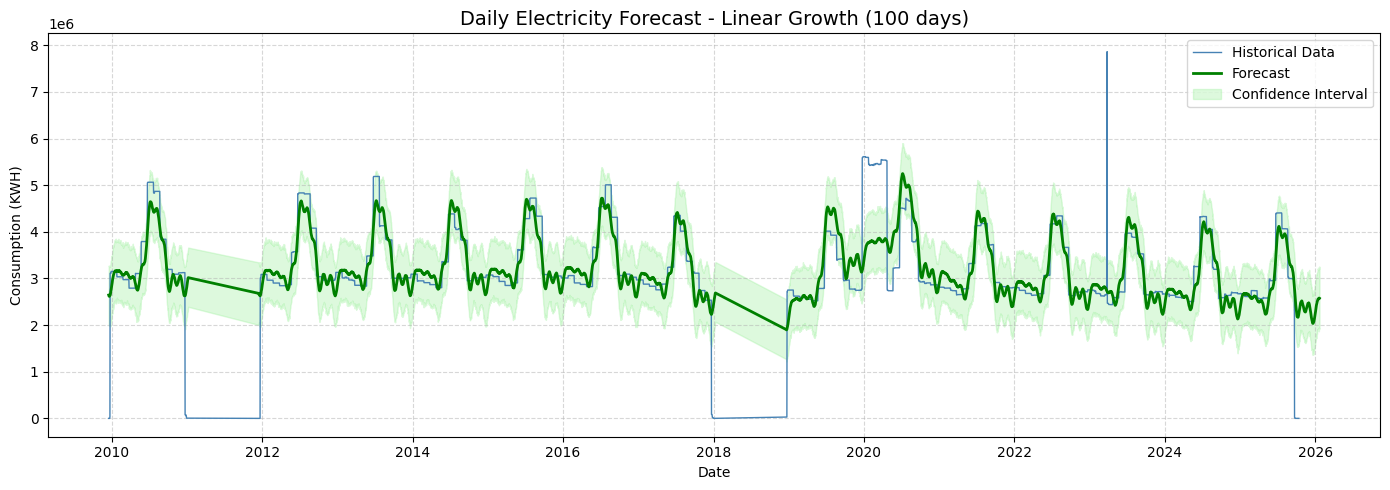


  → Forecast: 200 days

  Predicted values (200 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,279,989.75         1,662,816.34         2,974,286.44
  2025-10-15              2,305,815.78         1,711,787.16         2,918,940.29
  2025-10-16              2,328,780.02         1,684,661.69         2,999,870.47
  2025-10-17              2,354,619.46         1,737,918.33         2,996,728.60
  2025-10-18              2,387,362.84         1,732,562.48         3,023,474.20
  2025-10-19              2,414,120.29         1,778,608.47         3,035,196.90
  2025-10-20              2,449,333.42         1,796,404.96         3,122,774.49
  2025-10-21              2,470,808.39         1,798,809.53         3,127,514.47
  2025-10-22              2,486,348.72         1,828,878.93         3,140,047.61
  2025-10-23              2,494,336.42         1,826,279

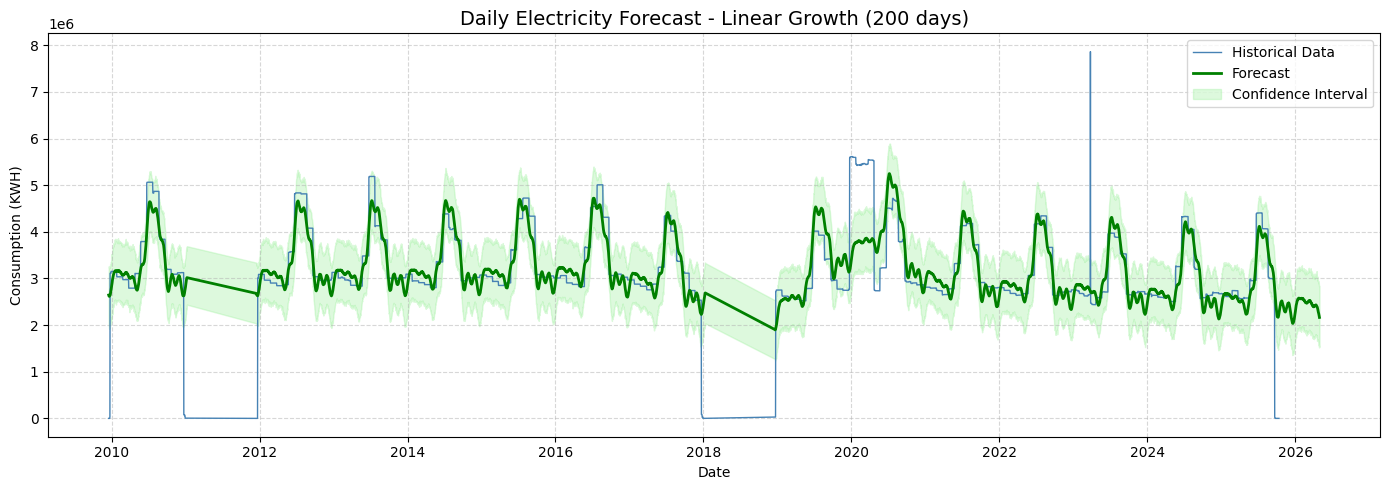


  → Forecast: 365 days

  Predicted values (365 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,279,989.75         1,609,002.14         2,851,977.93
  2025-10-15              2,305,815.78         1,663,513.50         2,913,787.00
  2025-10-16              2,328,780.02         1,649,401.24         2,917,410.94
  2025-10-17              2,354,619.46         1,728,581.14         2,989,627.57
  2025-10-18              2,387,362.84         1,731,592.44         3,077,378.48
  2025-10-19              2,414,120.29         1,792,354.44         3,052,718.00
  2025-10-20              2,449,333.42         1,859,340.39         3,146,552.47
  2025-10-21              2,470,808.39         1,828,567.30         3,125,924.87
  2025-10-22              2,486,348.72         1,840,322.17         3,101,942.83
  2025-10-23              2,494,336.42         1,868,581

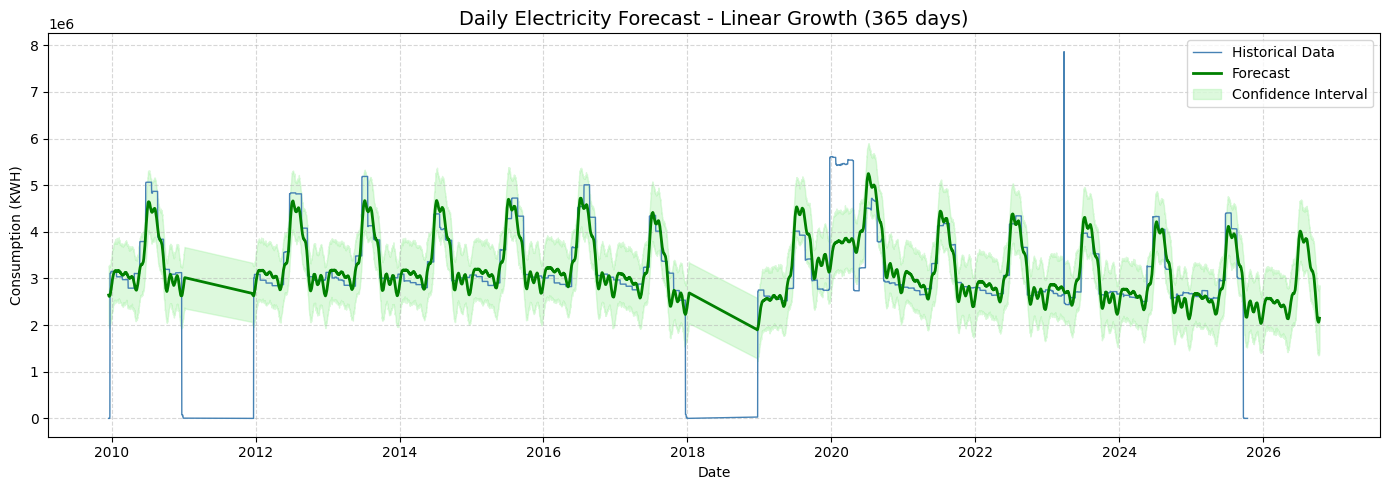

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Linear Growth - Daily (365 days)         289,490.86 735673.29%   0.6311

[2] Logistic Growth

  → Forecast: 100 days

  Predicted values (100 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,246,500.96         1,624,494.50         2,976,995.21
  2025-10-15              2,272,415.02         1,571,293.46         3,019,910.35
  2025-10-16              2,295,008.46         1,626,901.97         3,027,371.45
  2025-10-17              2,321,045.63         1,603,489.86         3,018,091.68
  2025-10-18              2,353,986.81         1,614,403.62         3,078,897.66
  2025-10-19              2,381,011.45         1,707,723.61         3,100,231.79
  2025-10-20              2,416,520.36         1,622,923

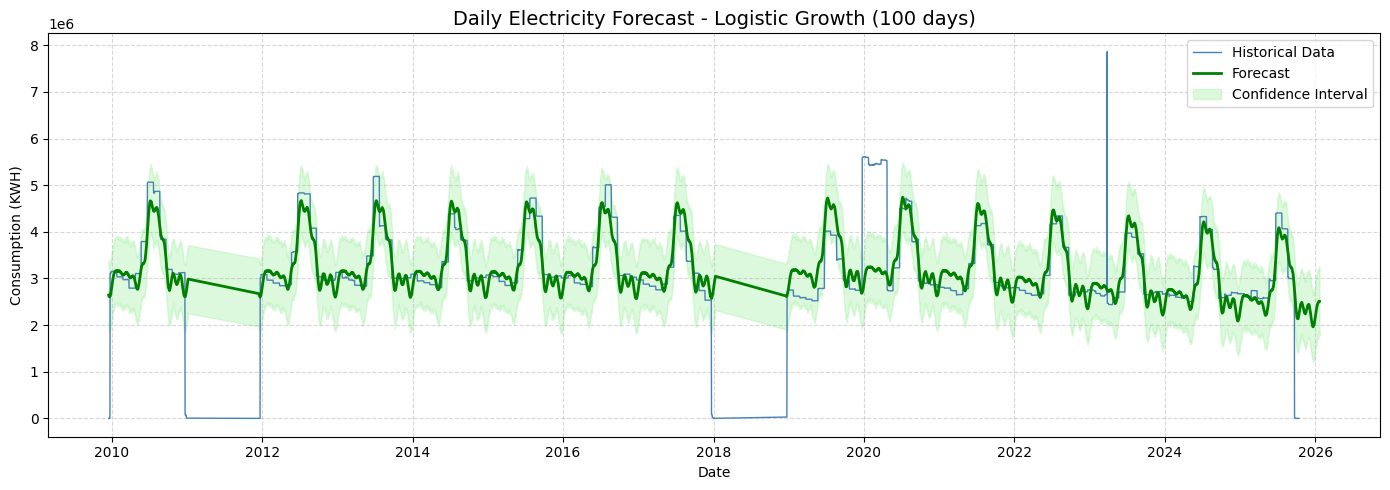


  → Forecast: 200 days

  Predicted values (200 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,246,500.96         1,512,762.19         2,932,694.32
  2025-10-15              2,272,415.02         1,569,877.27         2,964,322.70
  2025-10-16              2,295,008.46         1,556,752.43         2,998,842.05
  2025-10-17              2,321,045.63         1,613,266.59         3,031,301.44
  2025-10-18              2,353,986.81         1,662,469.41         3,103,170.25
  2025-10-19              2,381,011.45         1,676,855.47         3,095,105.29
  2025-10-20              2,416,520.36         1,692,951.44         3,094,271.66
  2025-10-21              2,438,259.45         1,724,220.99         3,151,479.48
  2025-10-22              2,454,107.15         1,761,747.12         3,171,865.88
  2025-10-23              2,461,881.63         1,740,581

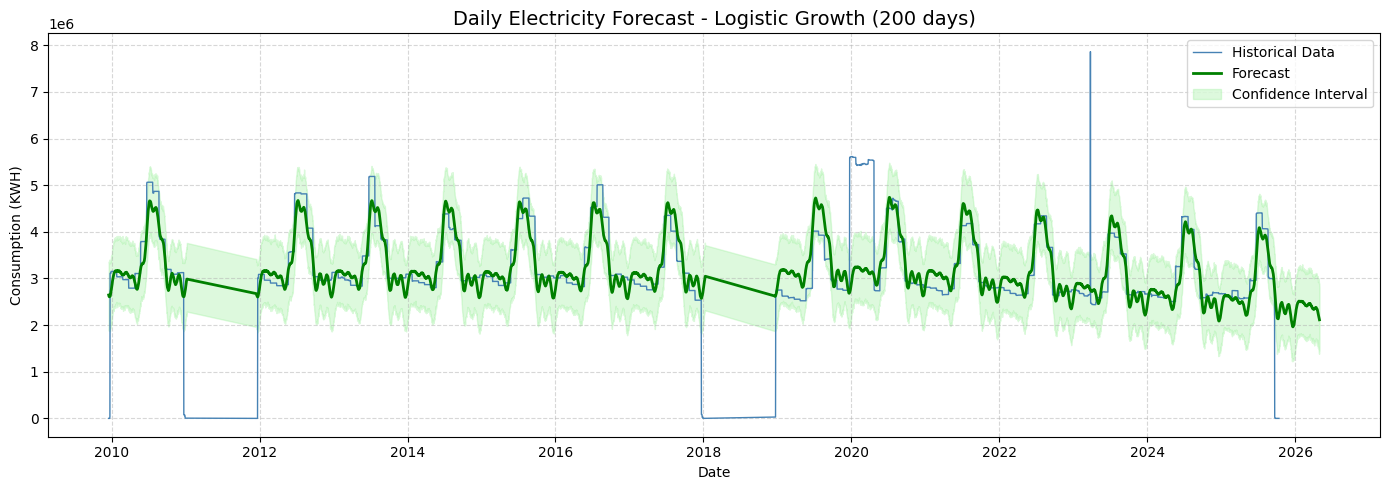


  → Forecast: 365 days

  Predicted values (365 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,246,500.96         1,401,493.37         2,930,554.86
  2025-10-15              2,272,415.02         1,489,478.53         2,976,110.71
  2025-10-16              2,295,008.46         1,558,260.21         2,993,997.59
  2025-10-17              2,321,045.63         1,558,290.87         3,029,580.44
  2025-10-18              2,353,986.81         1,631,253.07         3,085,134.82
  2025-10-19              2,381,011.45         1,624,026.25         3,089,284.56
  2025-10-20              2,416,520.36         1,700,693.20         3,136,837.61
  2025-10-21              2,438,259.45         1,709,867.70         3,130,042.86
  2025-10-22              2,454,107.15         1,782,487.81         3,220,744.62
  2025-10-23              2,461,881.63         1,793,996

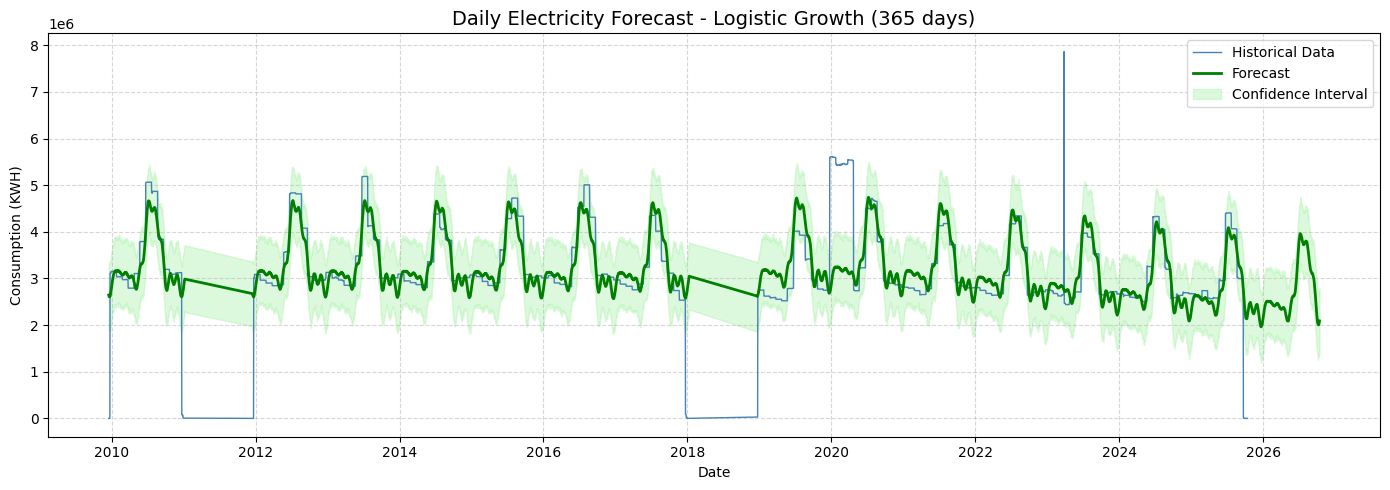

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Logistic Growth - Daily (365 days)       308,038.33 731830.16%   0.5368

[3] Flat Growth

  → Forecast: 100 days

  Predicted values (100 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,754,725.32         1,987,311.36         3,525,736.51
  2025-10-15              2,782,743.16         2,036,796.96         3,508,693.81
  2025-10-16              2,807,593.55         2,041,719.67         3,598,586.70
  2025-10-17              2,835,758.77         2,119,882.15         3,641,686.65
  2025-10-18              2,870,501.78         2,097,751.68         3,637,901.90
  2025-10-19              2,899,347.77         2,081,187.22         3,640,721.48
  2025-10-20              2,936,568.92         2,194,100.16 

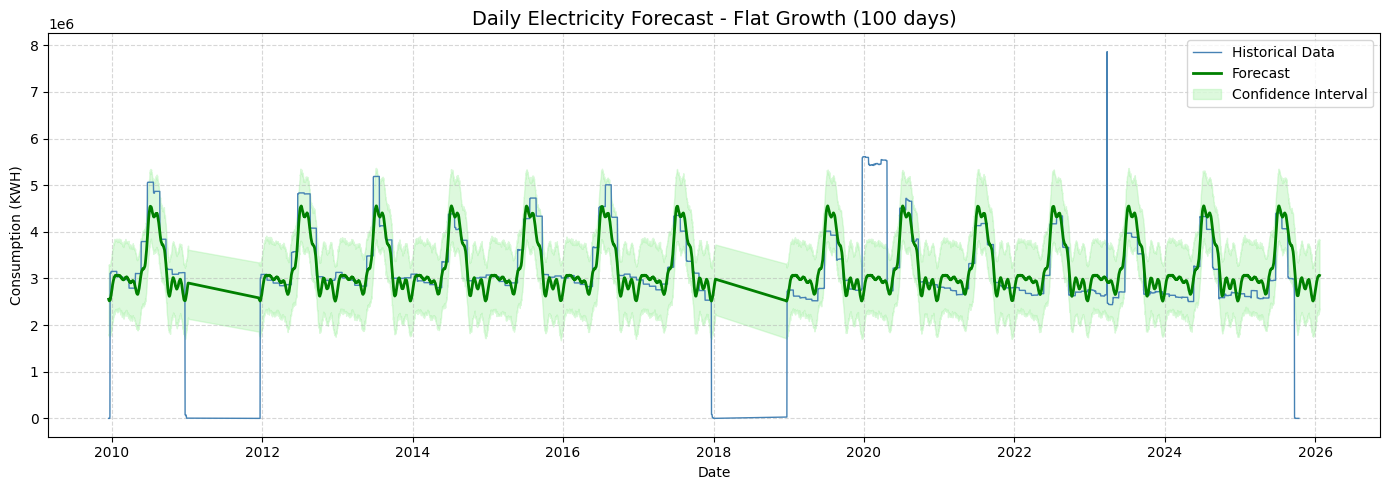


  → Forecast: 200 days

  Predicted values (200 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,754,725.32         1,993,173.47         3,566,716.23
  2025-10-15              2,782,743.16         2,033,132.25         3,550,804.11
  2025-10-16              2,807,593.55         1,977,716.14         3,542,117.61
  2025-10-17              2,835,758.77         2,118,971.16         3,599,186.05
  2025-10-18              2,870,501.78         2,117,683.27         3,650,710.38
  2025-10-19              2,899,347.77         2,154,321.45         3,732,079.82
  2025-10-20              2,936,568.92         2,223,389.19         3,705,448.09
  2025-10-21              2,960,595.58         2,154,729.36         3,722,695.50
  2025-10-22              2,977,913.58         2,214,175.66         3,698,108.95
  2025-10-23              2,987,219.71         2,205,971

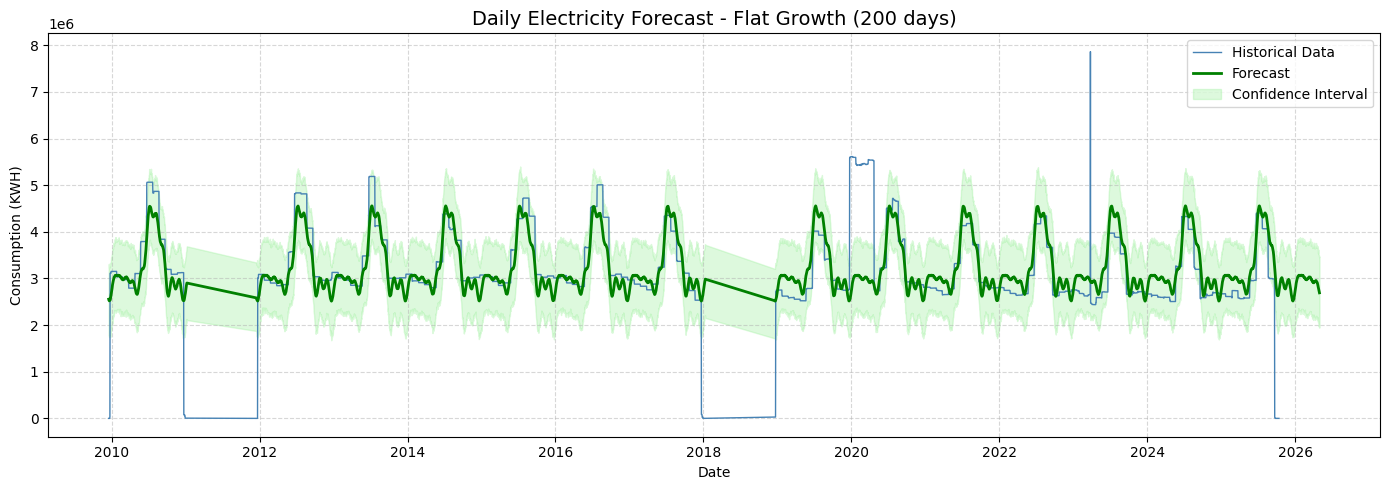


  → Forecast: 365 days

  Predicted values (365 days):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,754,725.32         2,013,506.77         3,512,942.63
  2025-10-15              2,782,743.16         2,010,224.27         3,514,990.18
  2025-10-16              2,807,593.55         2,033,414.89         3,586,493.17
  2025-10-17              2,835,758.77         2,078,787.01         3,604,892.60
  2025-10-18              2,870,501.78         2,070,776.00         3,636,201.81
  2025-10-19              2,899,347.77         2,153,549.33         3,690,971.55
  2025-10-20              2,936,568.92         2,232,920.30         3,741,087.40
  2025-10-21              2,960,595.58         2,185,277.55         3,690,125.56
  2025-10-22              2,977,913.58         2,227,108.40         3,708,772.04
  2025-10-23              2,987,219.71         2,198,766

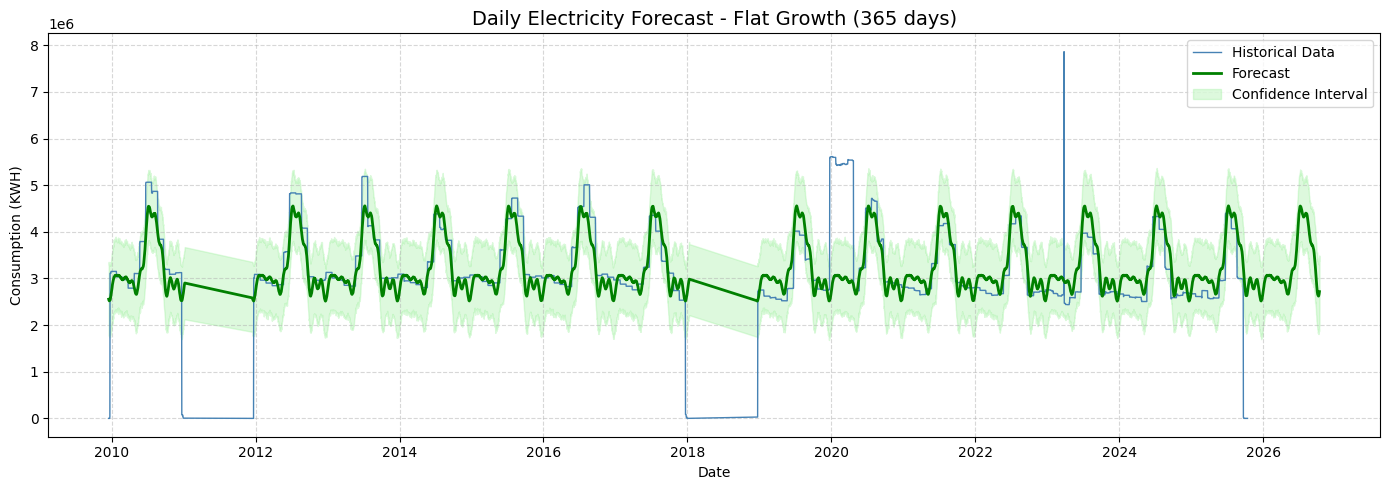


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Flat Growth - Daily (365 days)           331,815.77 730817.76%   0.4767

✓ Daily forecasting complete.


In [8]:
print("=" * 60)
print("DAILY DATASET FORECASTING")
print("=" * 60)

periods_list, freq = get_forecast_periods(freq_daily)
results_daily = []

# ── 1. LINEAR GROWTH ──────────────────────────────────────────
print("\n[1] Linear Growth")
model_linear_daily = Prophet(growth="linear")
model_linear_daily.fit(daily_agg)

for p in periods_list:
    future = model_linear_daily.make_future_dataframe(periods=p, freq=freq)
    forecast = model_linear_daily.predict(future)
    print(f"\n  → Forecast: {p} days")
    print_forecast_table(forecast, p, f"{p} days")
    plot_forecast(daily_agg, forecast, f"Daily Electricity Forecast - Linear Growth ({p} days)")
    # Evaluate on historical portion only (last period)
    if p == 365:
        merged = daily_agg.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        res = evaluate_model(merged["y"], merged["yhat"], f"Linear Growth - Daily ({p} days)")
        results_daily.append(res)

# ── 2. LOGISTIC GROWTH ────────────────────────────────────────
print("\n[2] Logistic Growth")
daily_agg["cap"]   = daily_agg["y"].max() * 1.2
daily_agg["floor"] = 0

model_logistic_daily = Prophet(growth="logistic")
model_logistic_daily.fit(daily_agg)

for p in periods_list:
    future = model_logistic_daily.make_future_dataframe(periods=p, freq=freq)
    future["cap"]   = daily_agg["cap"].iloc[0]
    future["floor"] = 0
    forecast = model_logistic_daily.predict(future)
    print(f"\n  → Forecast: {p} days")
    print_forecast_table(forecast, p, f"{p} days")
    plot_forecast(daily_agg, forecast, f"Daily Electricity Forecast - Logistic Growth ({p} days)")
    if p == 365:
        merged = daily_agg.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        res = evaluate_model(merged["y"], merged["yhat"], f"Logistic Growth - Daily ({p} days)")
        results_daily.append(res)

# ── 3. FLAT GROWTH ────────────────────────────────────────────
print("\n[3] Flat Growth")
# Remove cap/floor columns before flat model
daily_agg_flat = daily_agg[["ds", "y"]].copy()

model_flat_daily = Prophet(growth="flat")
model_flat_daily.fit(daily_agg_flat)

for p in periods_list:
    future = model_flat_daily.make_future_dataframe(periods=p, freq=freq)
    forecast = model_flat_daily.predict(future)
    print(f"\n  → Forecast: {p} days")
    print_forecast_table(forecast, p, f"{p} days")
    plot_forecast(daily_agg_flat, forecast, f"Daily Electricity Forecast - Flat Growth ({p} days)")
    if p == 365:
        merged = daily_agg_flat.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        res = evaluate_model(merged["y"], merged["yhat"], f"Flat Growth - Daily ({p} days)")
        results_daily.append(res)

print("\n✓ Daily forecasting complete.")

MONTHLY DATASET FORECASTING

[1] Linear Growth

  → Forecast: 1 month(s)

  Predicted values (1 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,606,897.33         1,820,536.20         3,372,888.84


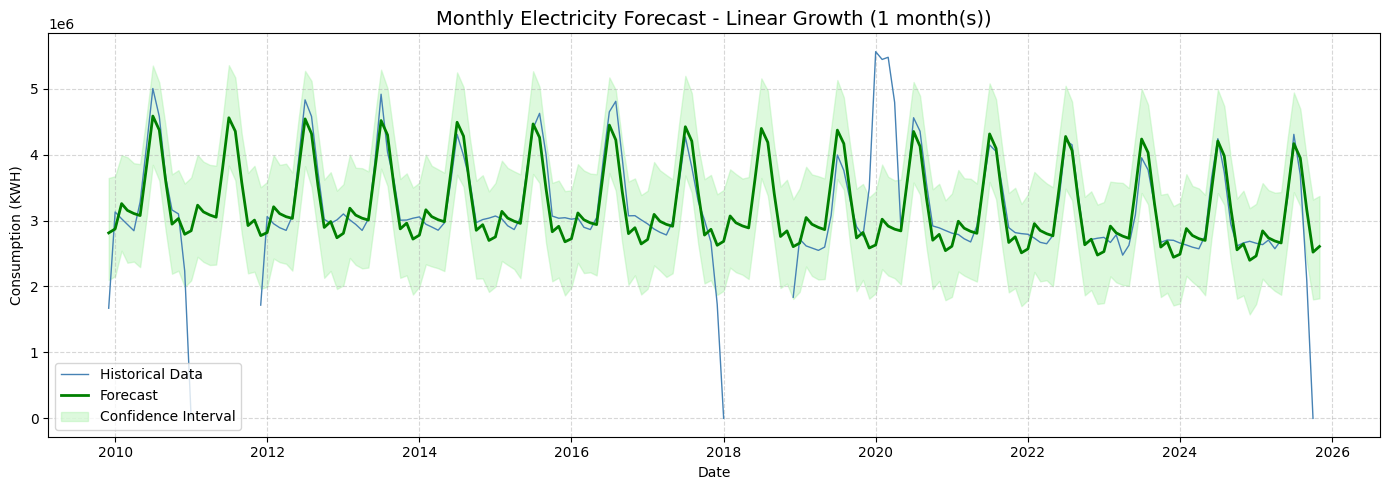


  → Forecast: 6 month(s)

  Predicted values (6 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,606,897.33         1,816,749.18         3,343,866.16
  2025-12-01              2,363,699.09         1,609,784.94         3,128,033.79
  2026-01-01              2,422,955.74         1,630,571.72         3,172,350.30
  2026-02-01              2,805,884.37         2,007,963.57         3,603,343.77
  2026-03-01              2,701,576.23         1,960,044.12         3,450,389.39
  2026-04-01              2,653,101.14         1,939,919.71         3,437,416.22


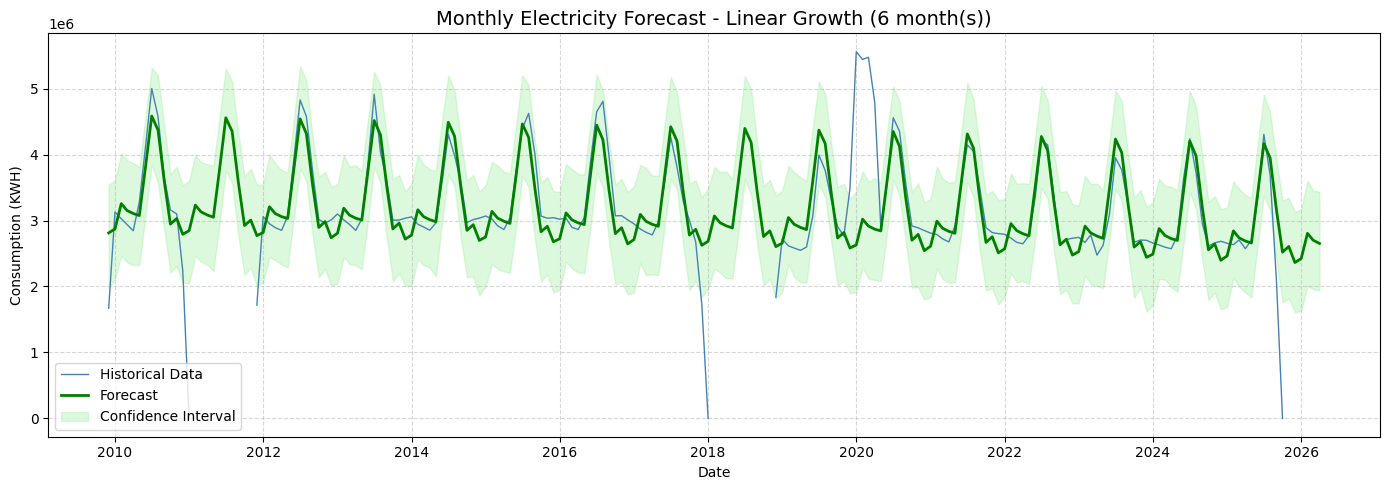


  → Forecast: 9 month(s)

  Predicted values (9 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,606,897.33         1,873,625.54         3,374,675.58
  2025-12-01              2,363,699.09         1,606,779.30         3,104,050.12
  2026-01-01              2,422,955.74         1,674,080.29         3,208,987.82
  2026-02-01              2,805,884.37         1,993,039.36         3,521,029.02
  2026-03-01              2,701,576.23         1,986,845.39         3,489,213.32
  2026-04-01              2,653,101.14         1,928,483.32         3,437,543.20
  2026-05-01              2,621,480.79         1,802,207.38         3,312,265.08
  2026-06-01              3,371,926.53         2,663,089.71         4,157,994.65
  2026-07-01              4,127,639.70         3,348,040.68         4,888,574.85


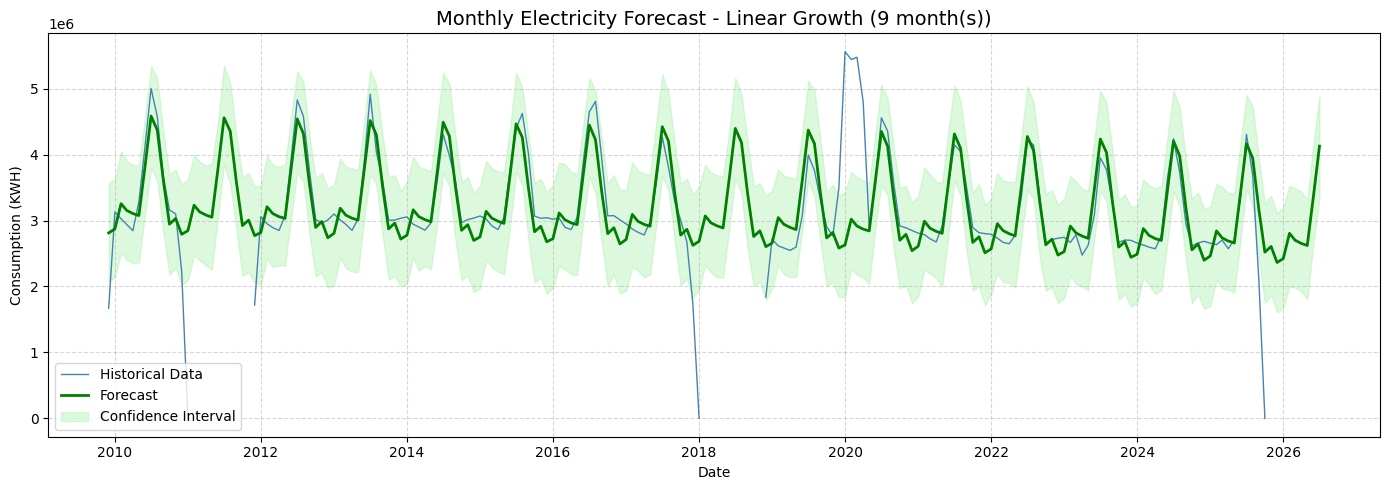


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Linear Growth - Monthly                  313,946.23  62559.31%   0.4855

[2] Logistic Growth

  → Forecast: 1 month(s)

  Predicted values (1 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,607,657.36         1,846,906.61         3,370,462.50


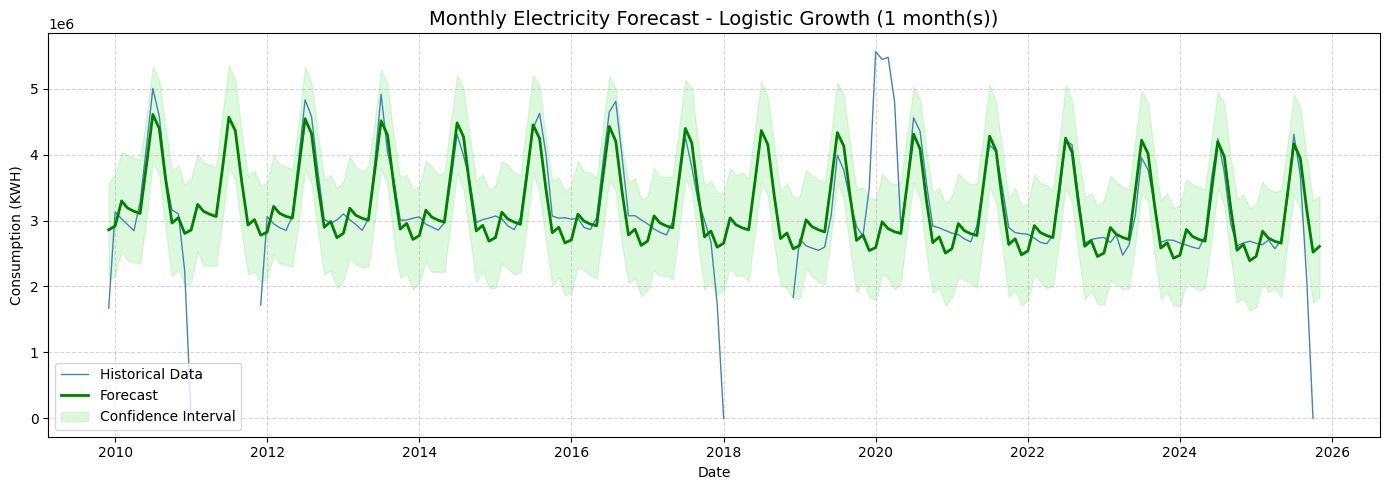


  → Forecast: 6 month(s)

  Predicted values (6 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,607,657.36         1,826,727.39         3,372,072.99
  2025-12-01              2,365,037.47         1,652,710.53         3,147,466.27
  2026-01-01              2,424,106.74         1,708,204.84         3,177,737.56
  2026-02-01              2,808,550.54         2,043,371.32         3,568,032.04
  2026-03-01              2,704,143.73         1,959,525.36         3,460,732.14
  2026-04-01              2,656,657.12         1,905,925.04         3,386,536.73


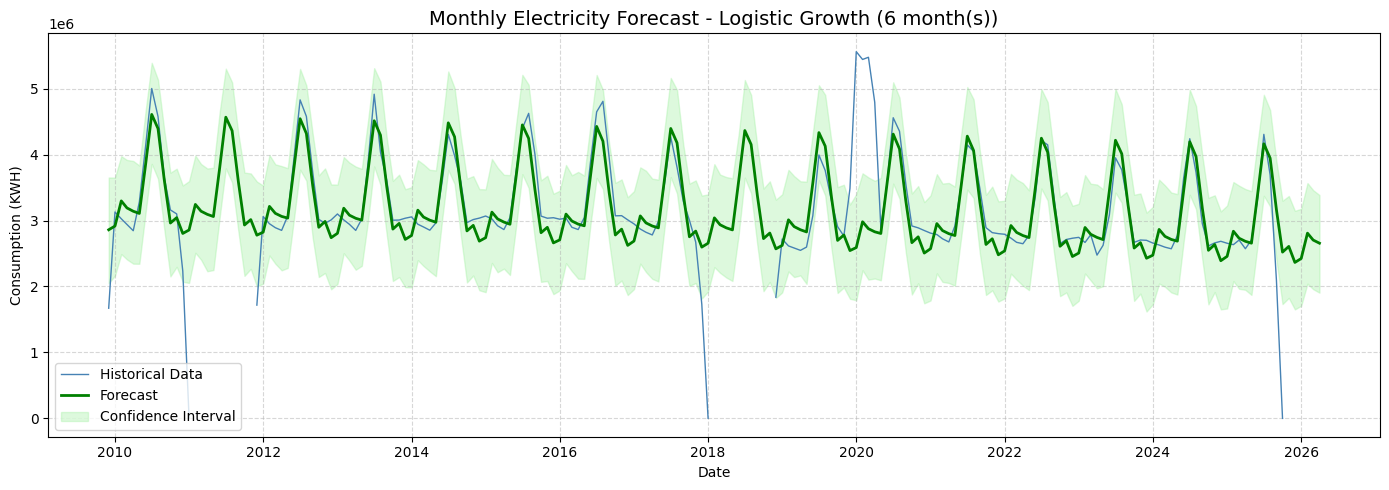


  → Forecast: 9 month(s)

  Predicted values (9 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,607,657.36         1,861,851.42         3,368,013.05
  2025-12-01              2,365,037.47         1,631,422.67         3,138,289.82
  2026-01-01              2,424,106.74         1,673,282.27         3,170,310.42
  2026-02-01              2,808,550.54         2,117,837.56         3,581,399.50
  2026-03-01              2,704,143.73         1,998,442.01         3,471,054.73
  2026-04-01              2,656,657.12         1,866,568.65         3,514,518.09
  2026-05-01              2,626,334.33         1,835,946.92         3,348,103.43
  2026-06-01              3,375,726.09         2,627,606.26         4,160,287.96
  2026-07-01              4,132,734.66         3,393,297.69         4,861,797.15


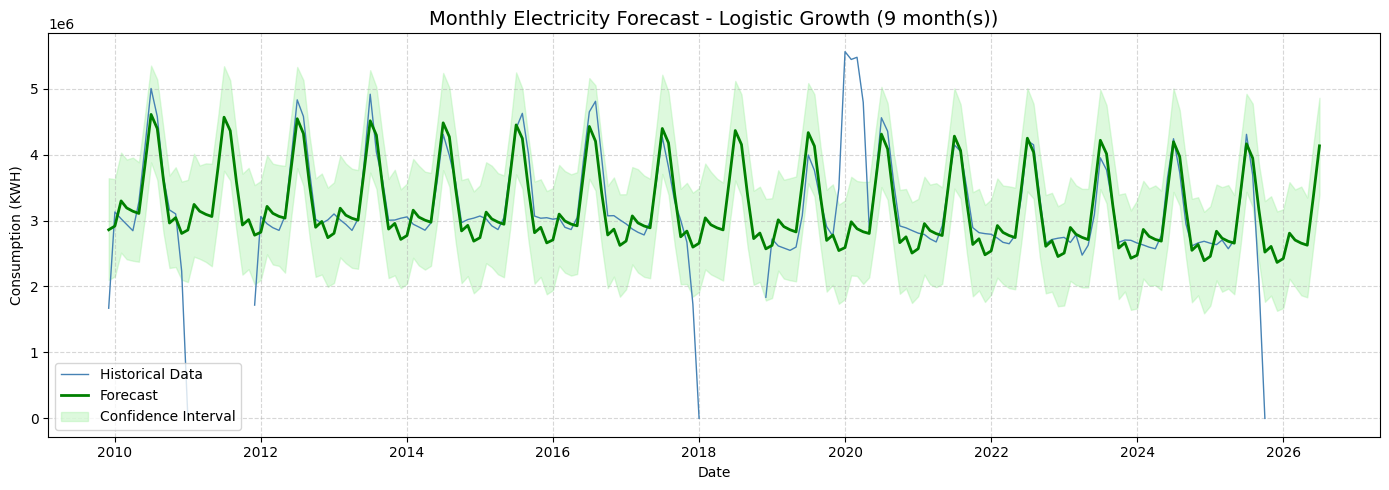


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Logistic Growth - Monthly                314,493.74  62561.44%   0.4786

[3] Flat Growth

  → Forecast: 1 month(s)

  Predicted values (1 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,843,873.11         2,046,330.14         3,597,198.74


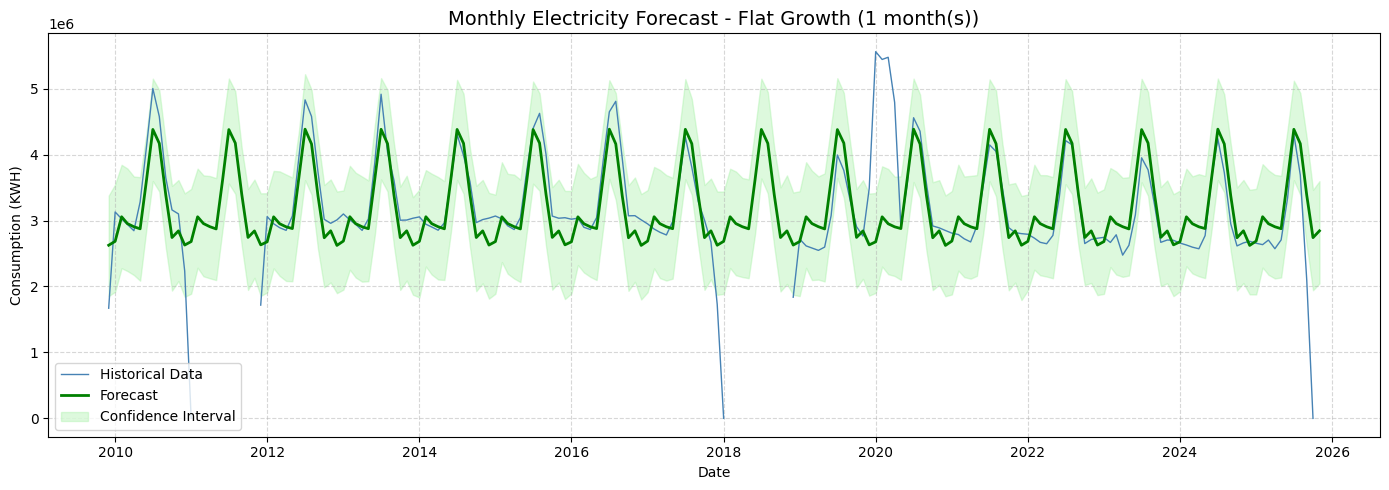


  → Forecast: 6 month(s)

  Predicted values (6 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,843,873.11         1,990,561.38         3,590,609.44
  2025-12-01              2,625,716.68         1,817,578.54         3,375,294.91
  2026-01-01              2,685,098.63         1,898,883.65         3,421,784.77
  2026-02-01              3,057,379.64         2,304,796.21         3,814,028.97
  2026-03-01              2,953,164.46         2,245,942.10         3,717,225.29
  2026-04-01              2,905,898.07         2,154,410.66         3,702,061.95


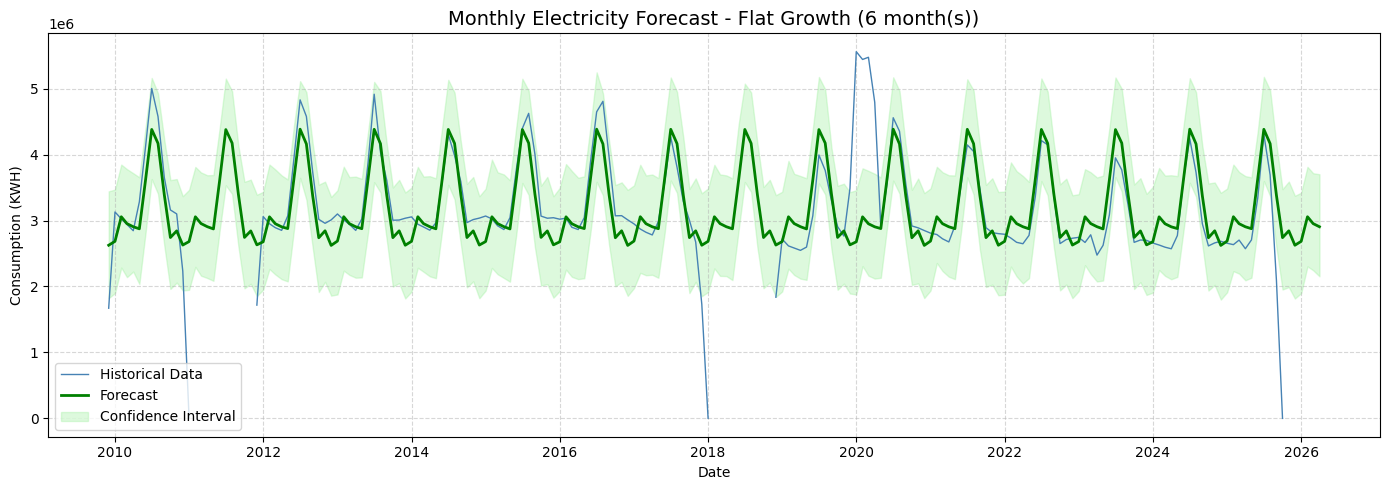


  → Forecast: 9 month(s)

  Predicted values (9 month(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,843,873.11         2,074,401.82         3,684,787.21
  2025-12-01              2,625,716.68         1,809,660.24         3,392,090.37
  2026-01-01              2,685,098.63         1,854,961.21         3,428,064.79
  2026-02-01              3,057,379.64         2,278,632.78         3,820,814.37
  2026-03-01              2,953,164.46         2,093,677.24         3,655,661.16
  2026-04-01              2,905,898.07         2,107,959.51         3,656,381.48
  2026-05-01              2,874,652.34         2,063,339.21         3,643,739.58
  2026-06-01              3,625,346.48         2,871,921.56         4,363,112.68
  2026-07-01              4,381,247.54         3,611,100.38         5,147,443.47


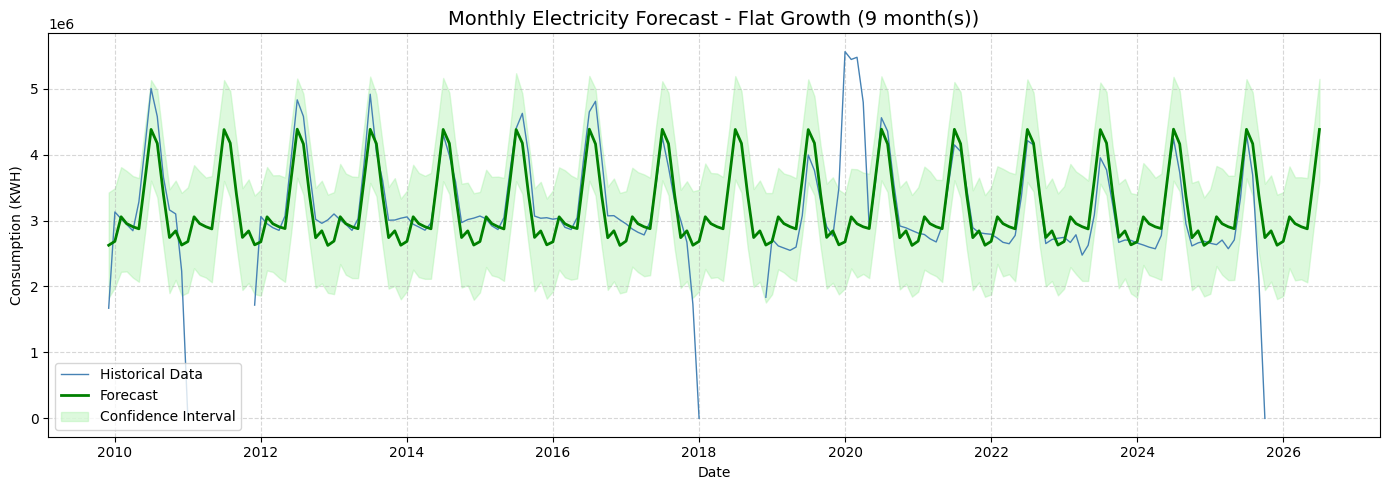


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Flat Growth - Monthly                    343,453.60  67849.24%   0.4595

✓ Monthly forecasting complete.


In [9]:
print("=" * 60)
print("MONTHLY DATASET FORECASTING")
print("=" * 60)

periods_list_m, freq_m = get_forecast_periods(freq_monthly)
results_monthly = []

# ── 1. LINEAR GROWTH ──────────────────────────────────────────
print("\n[1] Linear Growth")
model_linear_monthly = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_linear_monthly.add_seasonality(name='yearly', period=365.25, fourier_order=5)
model_linear_monthly.fit(monthly_df)

for p in periods_list_m:
    future = model_linear_monthly.make_future_dataframe(periods=p, freq=freq_m)
    forecast = model_linear_monthly.predict(future)
    print(f"\n  → Forecast: {p} month(s)")
    print_forecast_table(forecast, p, f"{p} month(s)")
    plot_forecast(monthly_df, forecast,
                  f"Monthly Electricity Forecast - Linear Growth ({p} month(s))")
    if p == 9:
        merged = monthly_df.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        merged = merged.dropna()
        res = evaluate_model(merged["y"], merged["yhat"], "Linear Growth - Monthly")
        results_monthly.append(res)

# ── 2. LOGISTIC GROWTH ────────────────────────────────────────
print("\n[2] Logistic Growth")
monthly_df["cap"]   = monthly_df["y"].max() * 1.2
monthly_df["floor"] = 0

model_logistic_monthly = Prophet(
    growth="logistic",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_logistic_monthly.add_seasonality(name='yearly', period=365.25, fourier_order=5)
model_logistic_monthly.fit(monthly_df)

for p in periods_list_m:
    future = model_logistic_monthly.make_future_dataframe(periods=p, freq=freq_m)
    future["cap"]   = monthly_df["cap"].iloc[0]
    future["floor"] = 0
    forecast = model_logistic_monthly.predict(future)
    print(f"\n  → Forecast: {p} month(s)")
    print_forecast_table(forecast, p, f"{p} month(s)")
    plot_forecast(monthly_df, forecast,
                  f"Monthly Electricity Forecast - Logistic Growth ({p} month(s))")
    if p == 9:
        merged = monthly_df.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        merged = merged.dropna()
        res = evaluate_model(merged["y"], merged["yhat"], "Logistic Growth - Monthly")
        results_monthly.append(res)

# ── 3. FLAT GROWTH ────────────────────────────────────────────
print("\n[3] Flat Growth")
monthly_df_flat = monthly_df[["ds", "y"]].copy()

model_flat_monthly = Prophet(
    growth="flat",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_flat_monthly.add_seasonality(name='yearly', period=365.25, fourier_order=5)
model_flat_monthly.fit(monthly_df_flat)

for p in periods_list_m:
    future = model_flat_monthly.make_future_dataframe(periods=p, freq=freq_m)
    forecast = model_flat_monthly.predict(future)
    print(f"\n  → Forecast: {p} month(s)")
    print_forecast_table(forecast, p, f"{p} month(s)")
    plot_forecast(monthly_df_flat, forecast,
                  f"Monthly Electricity Forecast - Flat Growth ({p} month(s))")
    if p == 9:
        merged = monthly_df_flat.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        merged = merged.dropna()
        res = evaluate_model(merged["y"], merged["yhat"], "Flat Growth - Monthly")
        results_monthly.append(res)

print("\n✓ Monthly forecasting complete.")

INFO:prophet:n_changepoints greater than number of observations. Using 12.


YEARLY DATASET FORECASTING

[1] Linear Growth

  → Forecast: 1 year(s)

  Predicted values (1 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              3,197,672.78         2,251,016.42         4,310,689.30


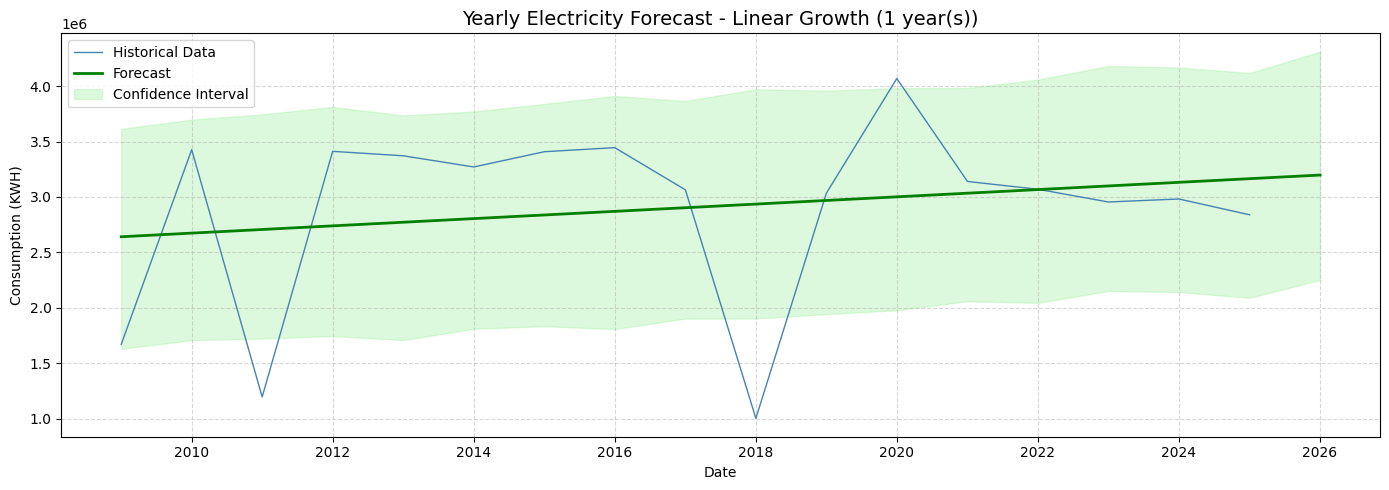


  → Forecast: 10 year(s)

  Predicted values (10 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              3,197,672.78         2,150,443.28         4,146,263.88
  2027-01-01              3,230,386.38         2,249,538.59         4,238,149.84
  2028-01-01              3,263,099.99         2,291,451.91         4,224,167.37
  2029-01-01              3,295,903.22         2,297,657.07         4,388,093.69
  2030-01-01              3,328,616.83         2,410,023.45         4,336,399.42
  2031-01-01              3,361,330.44         2,398,382.89         4,377,594.75
  2032-01-01              3,394,044.05         2,419,450.19         4,459,333.44
  2033-01-01              3,426,847.28         2,437,375.51         4,452,739.95
  2034-01-01              3,459,560.89         2,410,328.13         4,450,503.27
  2035-01-01              3,492,274.49         2,567

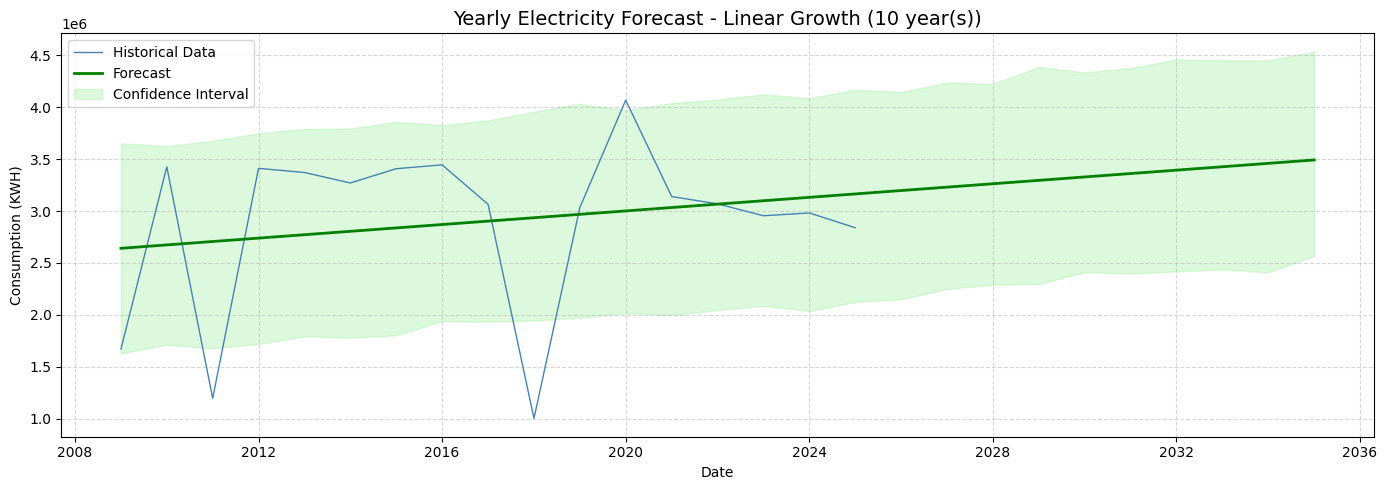


  → Forecast: 20 year(s)

  Predicted values (20 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              3,197,672.78         2,205,091.07         4,269,679.05
  2027-01-01              3,230,386.38         2,160,042.48         4,273,583.79
  2028-01-01              3,263,099.99         2,244,372.77         4,315,955.95
  2029-01-01              3,295,903.22         2,304,812.68         4,256,779.11
  2030-01-01              3,328,616.83         2,319,504.10         4,380,578.46
  2031-01-01              3,361,330.44         2,355,800.64         4,286,950.61
  2032-01-01              3,394,044.05         2,343,978.82         4,339,951.15
  2033-01-01              3,426,847.28         2,420,639.36         4,422,046.02
  2034-01-01              3,459,560.89         2,444,353.26         4,481,079.23
  2035-01-01              3,492,274.49         2,459

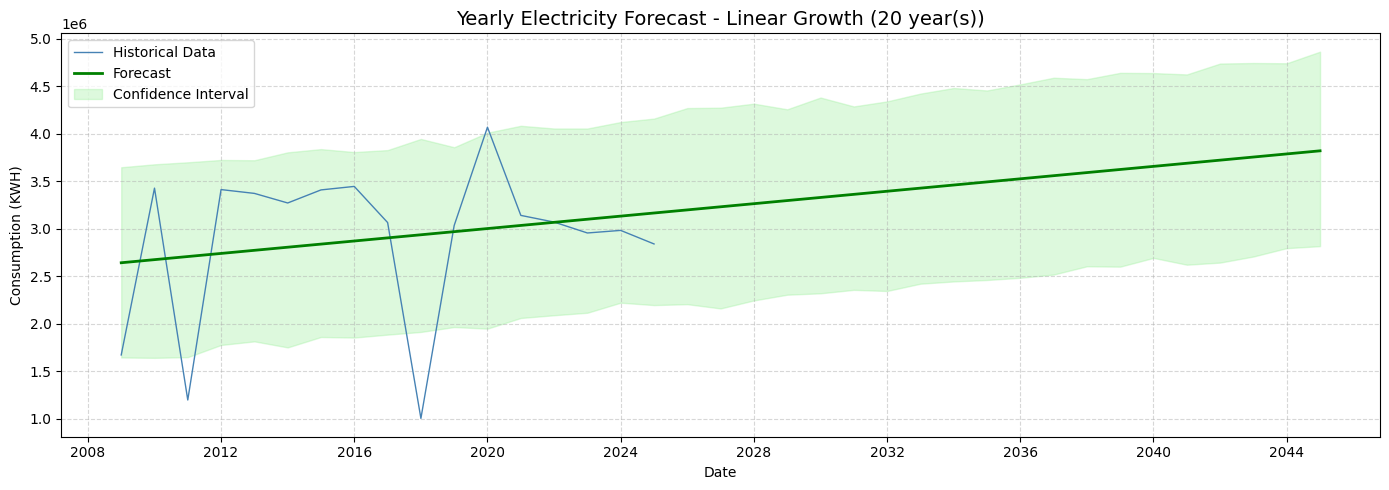

INFO:prophet:n_changepoints greater than number of observations. Using 12.



  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Linear Growth - Yearly                   592,484.34     31.93%   0.0398

[2] Logistic Growth

  → Forecast: 1 year(s)

  Predicted values (1 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              2,778,293.73         1,768,863.46         3,800,055.36


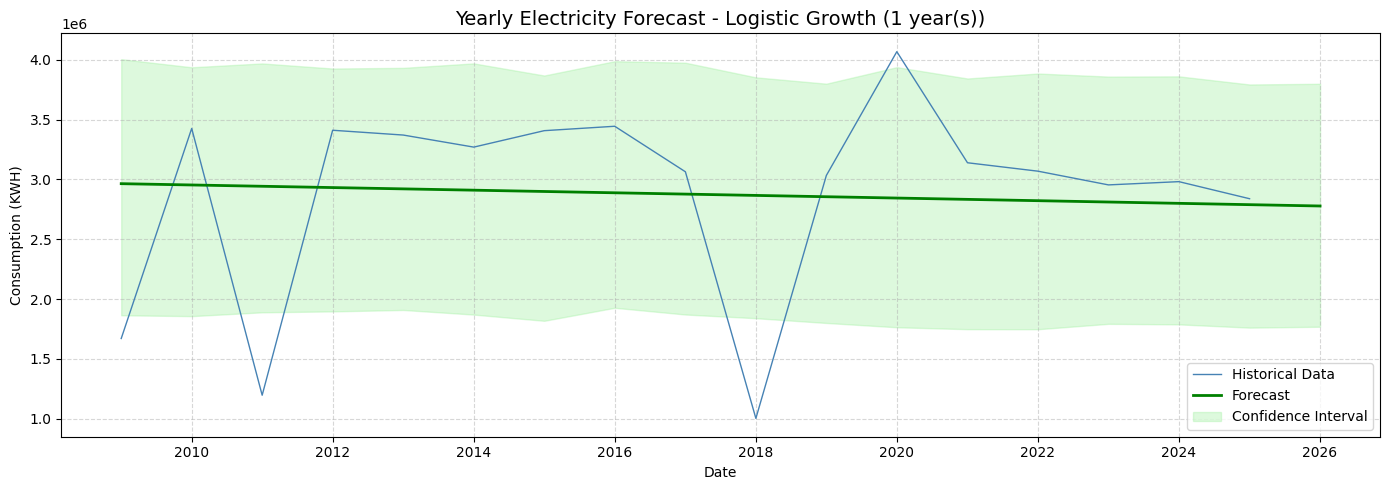


  → Forecast: 10 year(s)

  Predicted values (10 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              2,778,293.73         1,734,882.26         3,755,243.28
  2027-01-01              2,767,176.22         1,683,690.98         3,767,474.93
  2028-01-01              2,756,044.91         1,759,486.63         3,737,347.74
  2029-01-01              2,744,869.72         1,677,736.41         3,866,527.96
  2030-01-01              2,733,712.17         1,736,117.25         3,780,756.55
  2031-01-01              2,722,542.21         1,634,329.97         3,690,828.44
  2032-01-01              2,711,360.28         1,683,846.63         3,799,821.13
  2033-01-01              2,700,136.18         1,652,972.58         3,756,853.49
  2034-01-01              2,688,931.70         1,621,455.11         3,782,675.11
  2035-01-01              2,677,716.66         1,582

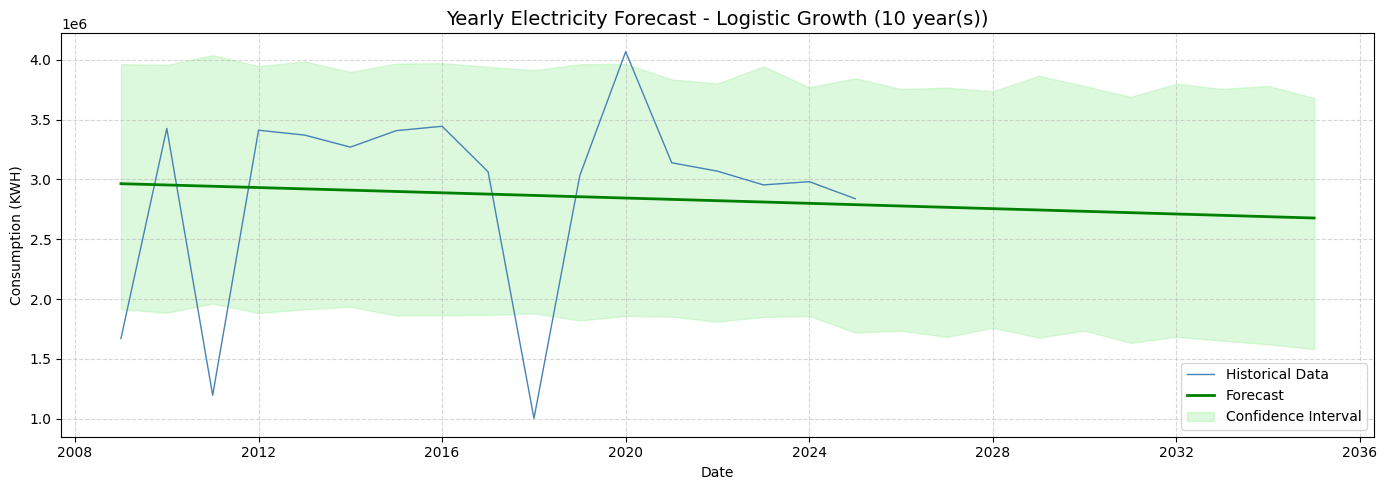


  → Forecast: 20 year(s)

  Predicted values (20 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              2,778,293.73         1,745,425.52         3,821,533.23
  2027-01-01              2,767,176.22         1,743,432.01         3,753,913.65
  2028-01-01              2,756,044.91         1,743,697.81         3,768,133.93
  2029-01-01              2,744,869.72         1,706,041.75         3,744,275.00
  2030-01-01              2,733,712.17         1,672,812.87         3,751,837.26
  2031-01-01              2,722,542.21         1,705,471.88         3,718,131.13
  2032-01-01              2,711,360.28         1,601,683.16         3,710,935.00
  2033-01-01              2,700,136.18         1,675,573.23         3,725,117.59
  2034-01-01              2,688,931.70         1,643,717.58         3,709,279.45
  2035-01-01              2,677,716.66         1,564

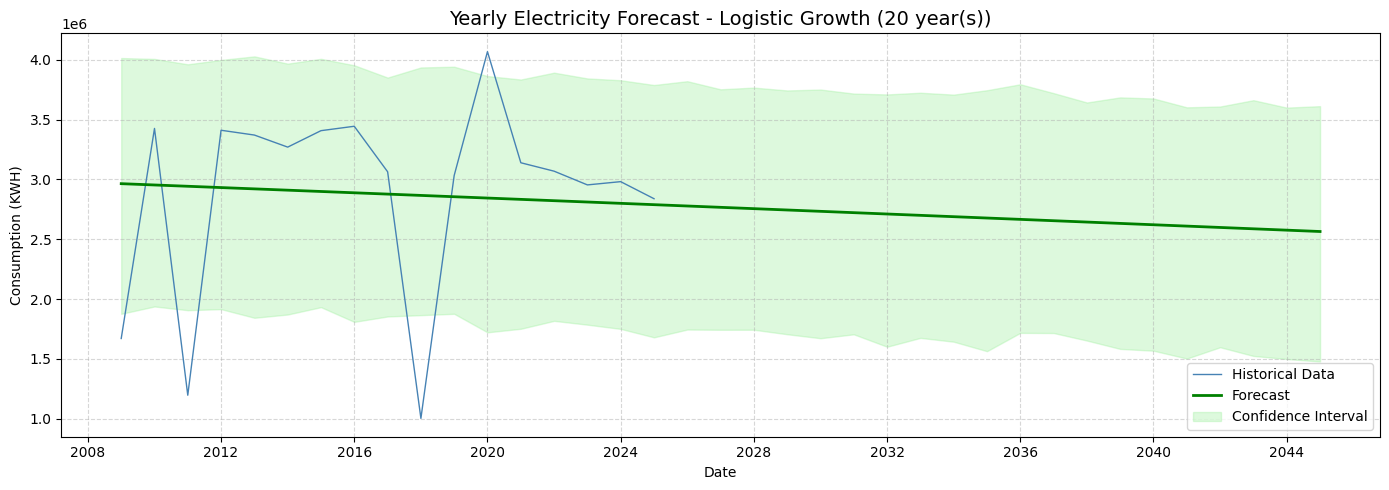

INFO:prophet:n_changepoints greater than number of observations. Using 12.



  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Logistic Growth - Yearly                 602,763.45     33.25%  -0.0320

[3] Flat Growth

  → Forecast: 1 year(s)

  Predicted values (1 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              2,902,906.80         1,882,740.31         3,931,480.57


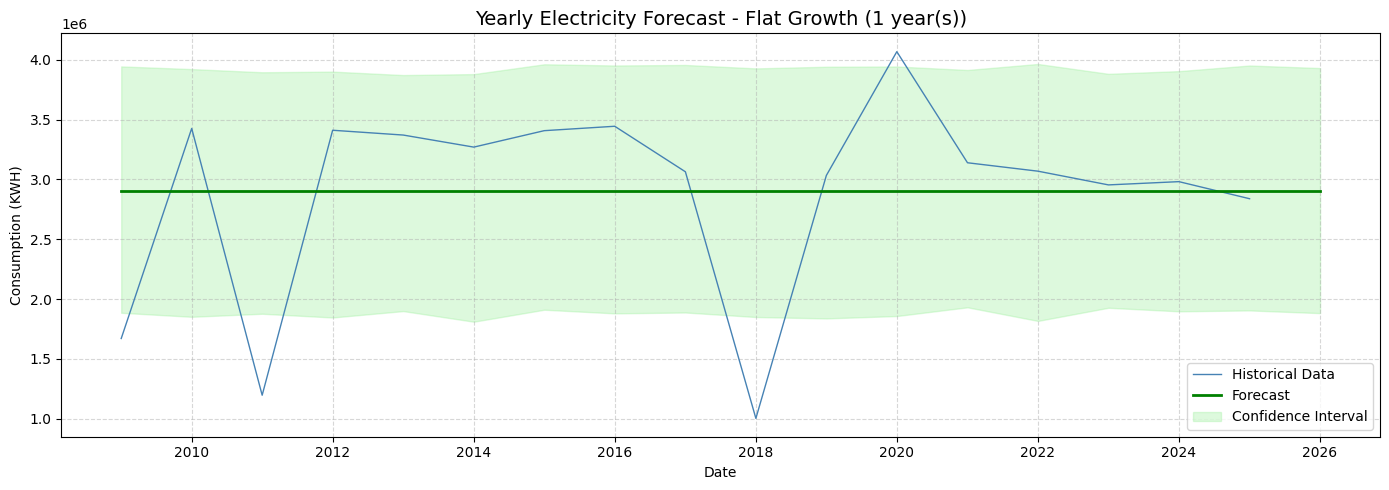


  → Forecast: 10 year(s)

  Predicted values (10 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              2,902,906.80         1,926,885.67         3,915,556.25
  2027-01-01              2,902,906.80         1,888,880.63         3,845,807.67
  2028-01-01              2,902,906.80         1,845,244.87         3,850,639.05
  2029-01-01              2,902,906.80         1,838,622.46         3,952,106.42
  2030-01-01              2,902,906.80         1,898,507.42         3,918,800.93
  2031-01-01              2,902,906.80         1,833,531.43         3,968,397.55
  2032-01-01              2,902,906.80         1,876,547.46         3,943,146.03
  2033-01-01              2,902,906.80         1,866,536.37         3,940,705.47
  2034-01-01              2,902,906.80         1,817,963.76         3,984,271.45
  2035-01-01              2,902,906.80         1,871

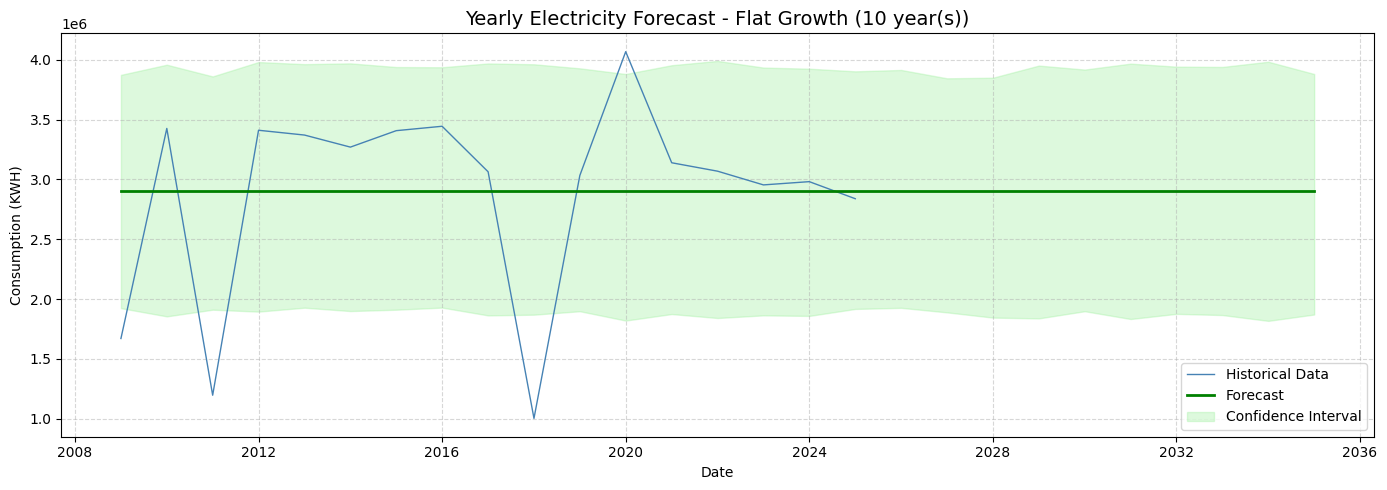


  → Forecast: 20 year(s)

  Predicted values (20 year(s)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              2,902,906.80         1,856,859.28         3,956,727.18
  2027-01-01              2,902,906.80         1,926,248.86         3,943,838.57
  2028-01-01              2,902,906.80         1,862,314.78         3,877,069.65
  2029-01-01              2,902,906.80         1,919,798.52         3,970,259.76
  2030-01-01              2,902,906.80         1,923,226.36         3,940,743.55
  2031-01-01              2,902,906.80         1,895,249.43         3,990,817.87
  2032-01-01              2,902,906.80         1,871,826.86         4,036,509.73
  2033-01-01              2,902,906.80         1,894,964.22         3,969,454.63
  2034-01-01              2,902,906.80         1,906,199.64         4,014,507.63
  2035-01-01              2,902,906.80         1,845

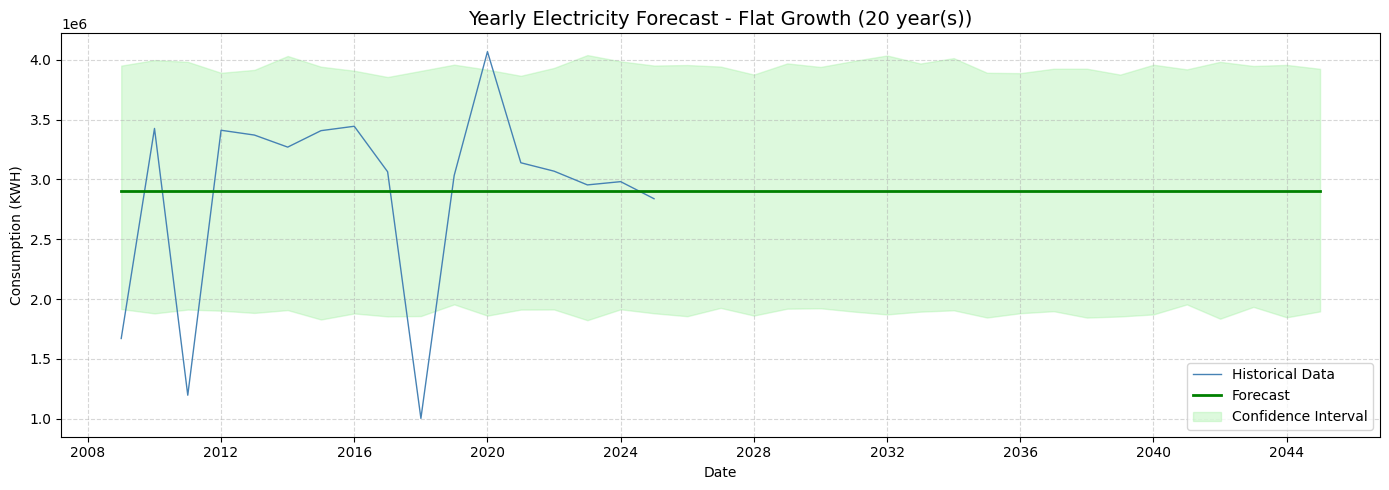


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Flat Growth - Yearly                     577,090.35     32.33%  -0.0000

✓ Yearly forecasting complete.


In [10]:
print("=" * 60)
print("YEARLY DATASET FORECASTING")
print("=" * 60)

periods_list_y, freq_y = get_forecast_periods(freq_yearly)
results_yearly = []

# ── 1. LINEAR GROWTH ──────────────────────────────────────────
print("\n[1] Linear Growth")
model_linear_yearly = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_linear_yearly.fit(yearly_df)

for p in periods_list_y:
    future = model_linear_yearly.make_future_dataframe(periods=p, freq=freq_y)
    forecast = model_linear_yearly.predict(future)
    print(f"\n  → Forecast: {p} year(s)")
    print_forecast_table(forecast, p, f"{p} year(s)")
    plot_forecast(yearly_df, forecast,
                  f"Yearly Electricity Forecast - Linear Growth ({p} year(s))")
    if p == 20:
        merged = yearly_df.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        merged = merged.dropna()
        res = evaluate_model(merged["y"], merged["yhat"], "Linear Growth - Yearly")
        results_yearly.append(res)

# ── 2. LOGISTIC GROWTH ────────────────────────────────────────
print("\n[2] Logistic Growth")
yearly_df["cap"]   = yearly_df["y"].max() * 1.2
yearly_df["floor"] = 0

model_logistic_yearly = Prophet(
    growth="logistic",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_logistic_yearly.fit(yearly_df)

for p in periods_list_y:
    future = model_logistic_yearly.make_future_dataframe(periods=p, freq=freq_y)
    future["cap"]   = yearly_df["cap"].iloc[0]
    future["floor"] = 0
    forecast = model_logistic_yearly.predict(future)
    print(f"\n  → Forecast: {p} year(s)")
    print_forecast_table(forecast, p, f"{p} year(s)")
    plot_forecast(yearly_df, forecast,
                  f"Yearly Electricity Forecast - Logistic Growth ({p} year(s))")
    if p == 20:
        merged = yearly_df.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        merged = merged.dropna()
        res = evaluate_model(merged["y"], merged["yhat"], "Logistic Growth - Yearly")
        results_yearly.append(res)

# ── 3. FLAT GROWTH ────────────────────────────────────────────
print("\n[3] Flat Growth")
yearly_df_flat = yearly_df[["ds", "y"]].copy()

model_flat_yearly = Prophet(
    growth="flat",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_flat_yearly.fit(yearly_df_flat)

for p in periods_list_y:
    future = model_flat_yearly.make_future_dataframe(periods=p, freq=freq_y)
    forecast = model_flat_yearly.predict(future)
    print(f"\n  → Forecast: {p} year(s)")
    print_forecast_table(forecast, p, f"{p} year(s)")
    plot_forecast(yearly_df_flat, forecast,
                  f"Yearly Electricity Forecast - Flat Growth ({p} year(s))")
    if p == 20:
        merged = yearly_df_flat.merge(forecast[["ds", "yhat"]], on="ds", how="inner")
        merged = merged.dropna()
        res = evaluate_model(merged["y"], merged["yhat"], "Flat Growth - Yearly")
        results_yearly.append(res)

print("\n✓ Yearly forecasting complete.")

SEASONALITY & CHANGEPOINT TUNING

[1] Daily - Custom Seasonality (yearly period=365, fourier=10 | weekly period=7, fourier=5)

  Predicted values (365 days (tuned seasonality)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,256,375.97         1,674,889.14         2,748,907.72
  2025-10-15              2,280,621.10         1,744,605.90         2,841,877.04
  2025-10-16              2,301,717.89         1,765,488.73         2,833,975.34
  2025-10-17              2,326,533.27         1,731,289.12         2,902,906.39
  2025-10-18              2,357,509.05         1,755,785.00         2,902,370.32
  2025-10-19              2,382,627.48         1,776,412.39         2,938,705.86
  2025-10-20              2,416,244.34         1,868,105.91         2,955,625.24
  2025-10-21              2,436,121.34         1,880,793.90         3,045,980.82
  2025-10-22   

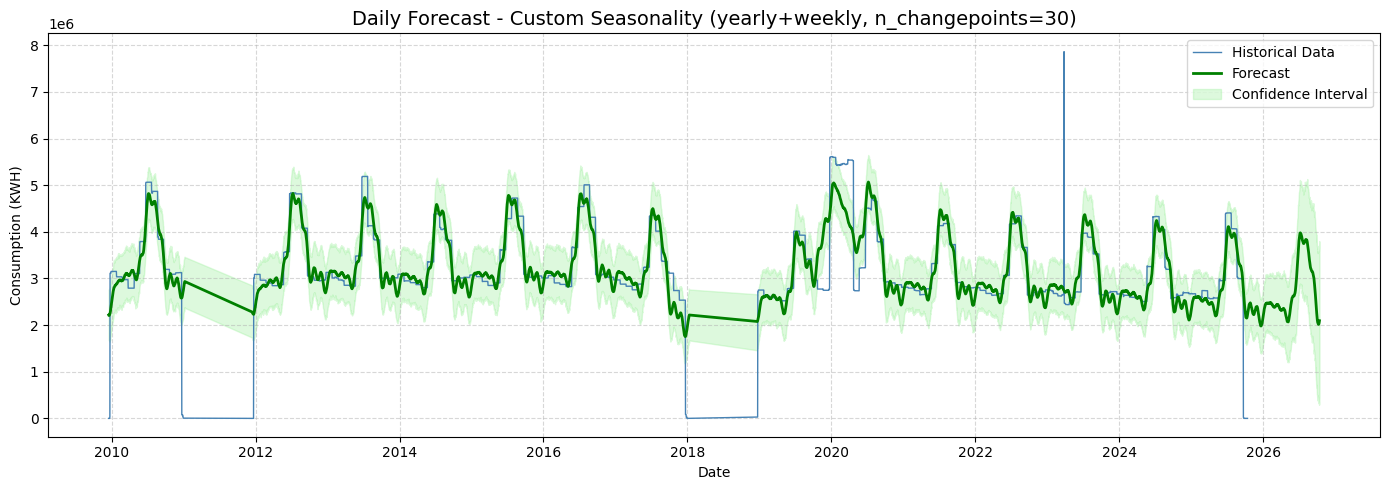


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Daily - Custom Seasonality Tuned         254,120.18 635842.16%   0.7222

[2] Daily - Alternative Seasonality (yearly period=365, fourier=3 | n_changepoints=10, scale=0.1)

  Predicted values (365 days (alternative seasonality)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-10-14              2,384,439.47         1,639,266.49         3,103,477.40
  2025-10-15              2,373,486.02         1,663,017.96         3,143,910.42
  2025-10-16              2,357,725.96         1,634,689.67         3,021,995.07
  2025-10-17              2,346,815.80         1,672,314.88         3,089,047.57
  2025-10-18              2,344,295.24         1,626,971.54         3,064,375.88
  2025-10-19              2,338,112.38         1,622,113.

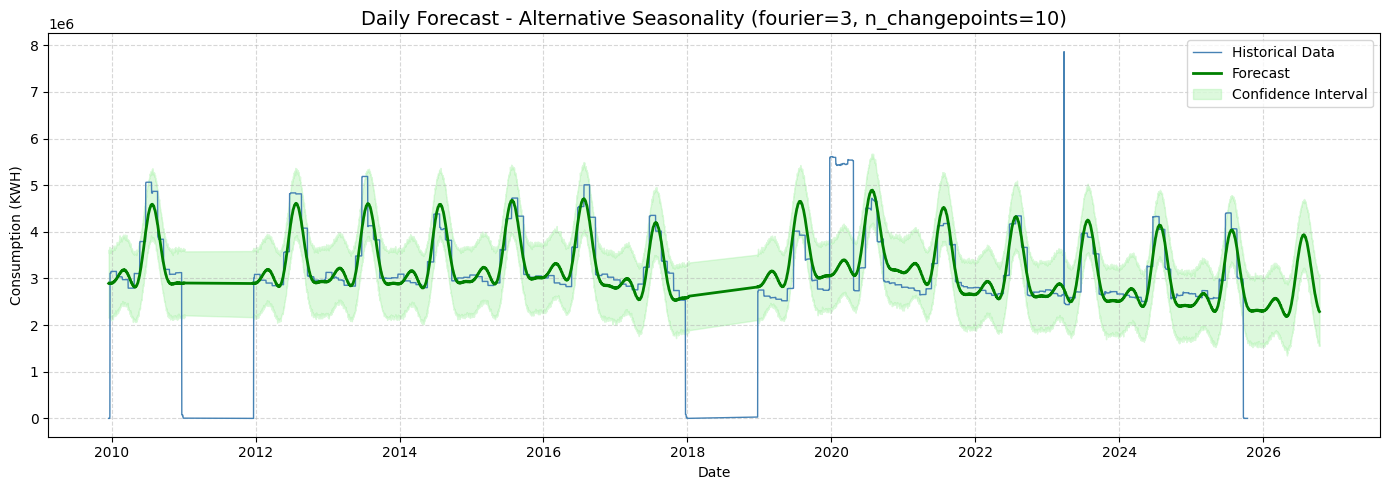


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Daily - Alternative Seasonality Tuned      310,680.03 807229.76%   0.5331

[3] Monthly - Custom Seasonality (period=365.25, fourier=5 | n_changepoints=15, scale=0.3)

  Predicted values (9 months (tuned seasonality)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2025-11-01              2,304,137.65         1,601,888.21         3,064,807.10
  2025-12-01              2,062,602.71         1,342,648.30         2,805,181.43
  2026-01-01              2,115,929.93         1,399,417.09         2,802,278.93
  2026-02-01              2,487,383.05         1,667,893.44         3,119,995.35
  2026-03-01              2,378,926.20         1,654,057.75         3,092,666.96
  2026-04-01              2,320,643.32         1,545,269.73         

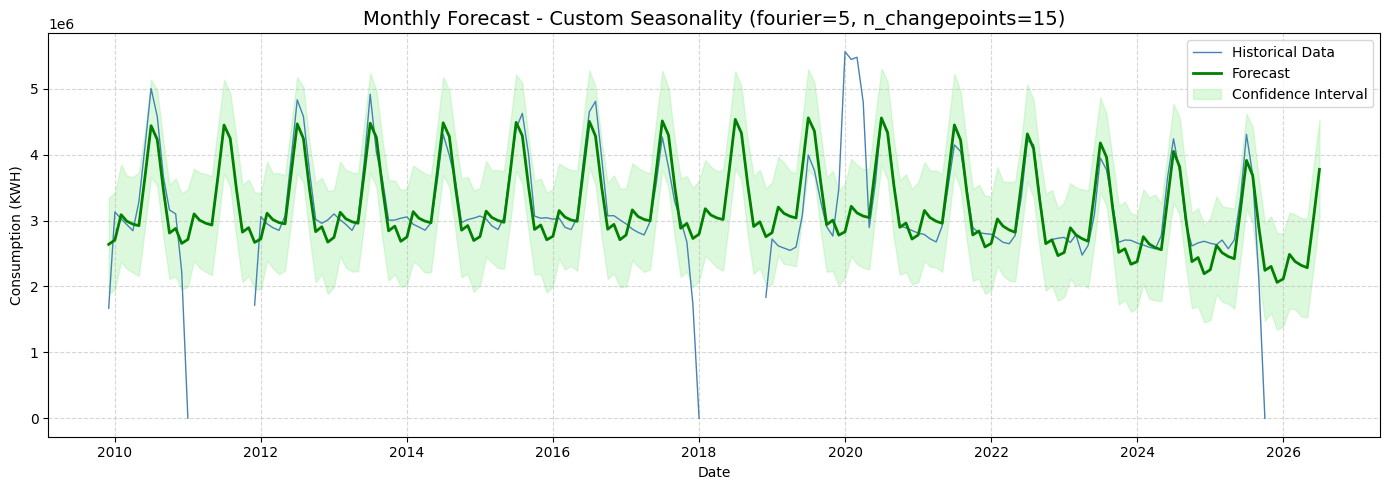


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Monthly - Custom Seasonality Tuned       322,904.87  55933.45%   0.5172

[4] Yearly - Changepoint Tuning (n_changepoints=5, scale=0.5)

  Predicted values (20 years (tuned changepoints)):
  Date                  Forecast (KWH)          Lower Bound          Upper Bound
  ---------------------------------------------------------------------------
  2026-01-01              3,198,078.64         2,150,342.02         4,157,188.35
  2027-01-01              3,230,817.51         2,214,380.50         4,178,087.97
  2028-01-01              3,263,556.37         2,161,486.22         4,220,726.85
  2029-01-01              3,296,384.94         2,285,982.12         4,415,893.28
  2030-01-01              3,329,123.80         2,414,914.32         4,349,618.66
  2031-01-01              3,361,862.67         2,370,797.25         4,304,890.95
  2032-01-01     

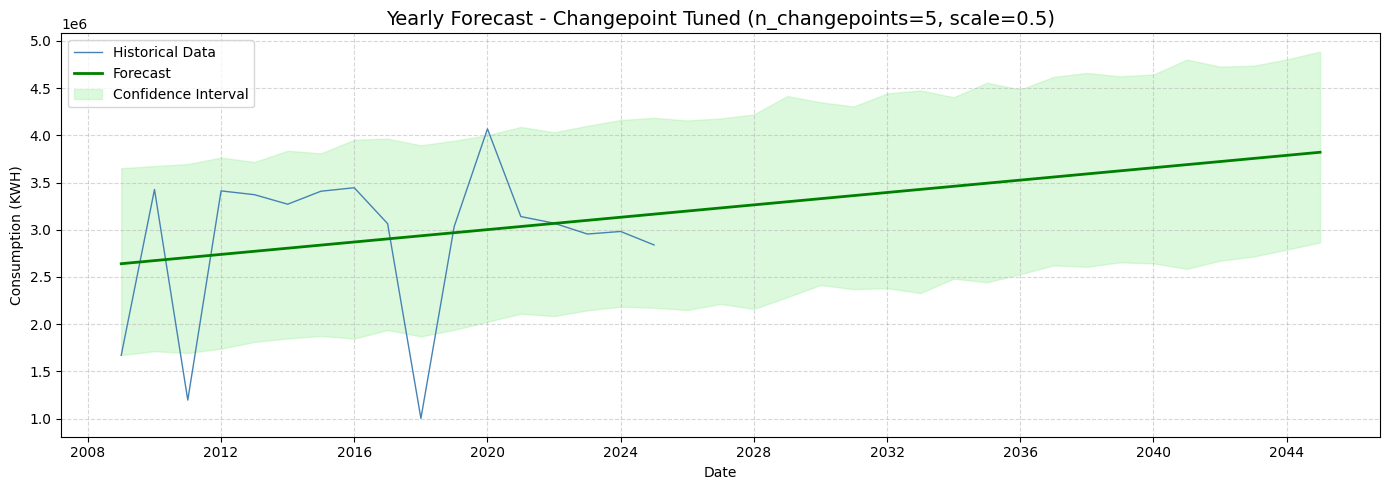


  Model                                           MAE       MAPE       R²
  ----------------------------------------------------------------------
  Yearly - Changepoint Tuned               592,473.62     31.93%   0.0399

✓ Seasonality & Changepoint tuning complete.


In [12]:
print("=" * 60)
print("SEASONALITY & CHANGEPOINT TUNING")
print("=" * 60)

results_tuned = []

# ── DAILY: Custom Seasonality ─────────────────────────────────
print("\n[1] Daily - Custom Seasonality (yearly period=365, fourier=10 | weekly period=7, fourier=5)")
model_seas_daily = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_changepoints=30,
    changepoint_prior_scale=0.5
)
model_seas_daily.add_seasonality(name='yearly', period=365.25, fourier_order=10)
model_seas_daily.add_seasonality(name='weekly', period=7, fourier_order=5)
model_seas_daily.fit(daily_agg[["ds", "y"]])

future = model_seas_daily.make_future_dataframe(periods=365, freq="D")
forecast_seas_daily = model_seas_daily.predict(future)
print_forecast_table(forecast_seas_daily, 365, "365 days (tuned seasonality)")
plot_forecast(daily_agg[["ds","y"]], forecast_seas_daily,
              "Daily Forecast - Custom Seasonality (yearly+weekly, n_changepoints=30)")

merged = daily_agg[["ds","y"]].merge(forecast_seas_daily[["ds","yhat"]], on="ds", how="inner")
res = evaluate_model(merged["y"], merged["yhat"], "Daily - Custom Seasonality Tuned")
results_tuned.append(res)

# ── DAILY: Different fourier values ───────────────────────────
print("\n[2] Daily - Alternative Seasonality (yearly period=365, fourier=3 | n_changepoints=10, scale=0.1)")
model_seas_daily2 = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_changepoints=10,
    changepoint_prior_scale=0.1
)
model_seas_daily2.add_seasonality(name='yearly', period=365.25, fourier_order=3)
model_seas_daily2.add_seasonality(name='weekly', period=7, fourier_order=3)
model_seas_daily2.fit(daily_agg[["ds", "y"]])

future2 = model_seas_daily2.make_future_dataframe(periods=365, freq="D")
forecast_seas_daily2 = model_seas_daily2.predict(future2)
print_forecast_table(forecast_seas_daily2, 365, "365 days (alternative seasonality)")
plot_forecast(daily_agg[["ds","y"]], forecast_seas_daily2,
              "Daily Forecast - Alternative Seasonality (fourier=3, n_changepoints=10)")

merged2 = daily_agg[["ds","y"]].merge(forecast_seas_daily2[["ds","yhat"]], on="ds", how="inner")
res2 = evaluate_model(merged2["y"], merged2["yhat"], "Daily - Alternative Seasonality Tuned")
results_tuned.append(res2)

# ── MONTHLY: Custom Seasonality ───────────────────────────────
print("\n[3] Monthly - Custom Seasonality (period=365.25, fourier=5 | n_changepoints=15, scale=0.3)")

# Use only ds and y columns to avoid cap/floor contamination
monthly_clean = monthly_df[["ds", "y"]].copy()

model_seas_monthly = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_changepoints=15,
    changepoint_prior_scale=0.3
)
model_seas_monthly.add_seasonality(name='yearly', period=365.25, fourier_order=5)
model_seas_monthly.fit(monthly_clean)

future_m = model_seas_monthly.make_future_dataframe(periods=9, freq="MS")
forecast_seas_monthly = model_seas_monthly.predict(future_m)
print_forecast_table(forecast_seas_monthly, 9, "9 months (tuned seasonality)")
plot_forecast(monthly_clean, forecast_seas_monthly,
              "Monthly Forecast - Custom Seasonality (fourier=5, n_changepoints=15)")

merged_m = monthly_clean.merge(forecast_seas_monthly[["ds","yhat"]], on="ds", how="inner")
merged_m = merged_m.dropna()
res_m = evaluate_model(merged_m["y"], merged_m["yhat"], "Monthly - Custom Seasonality Tuned")
results_tuned.append(res_m)

# ── YEARLY: Changepoint Tuning ────────────────────────────────
print("\n[4] Yearly - Changepoint Tuning (n_changepoints=5, scale=0.5)")

yearly_clean = yearly_df[["ds", "y"]].copy()

model_cp_yearly = Prophet(
    growth="linear",
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_changepoints=5,
    changepoint_prior_scale=0.5
)
model_cp_yearly.fit(yearly_clean)

future_y = model_cp_yearly.make_future_dataframe(periods=20, freq="YS")
forecast_cp_yearly = model_cp_yearly.predict(future_y)
print_forecast_table(forecast_cp_yearly, 20, "20 years (tuned changepoints)")
plot_forecast(yearly_clean, forecast_cp_yearly,
              "Yearly Forecast - Changepoint Tuned (n_changepoints=5, scale=0.5)")

merged_y = yearly_clean.merge(forecast_cp_yearly[["ds","yhat"]], on="ds", how="inner")
merged_y = merged_y.dropna()
res_y = evaluate_model(merged_y["y"], merged_y["yhat"], "Yearly - Changepoint Tuned")
results_tuned.append(res_y)

print("\n✓ Seasonality & Changepoint tuning complete.")

BOROUGH-LEVEL FORECASTING (Extra Credit)
  BROOKLYN: 5027 daily records
  MANHATTAN: 5080 daily records
  BRONX: 5028 daily records
  QUEENS: 5078 daily records
  STATEN ISLAND: 5027 daily records

Training & forecasting per borough (365 days)...

── BROOKLYN ──

  Forecast for BROOKLYN (next 10 days shown):
  Date                Forecast (KWH)              Lower              Upper
  ----------------------------------------------------------------------
  2025-09-30              800,219.71         622,912.37         977,775.56
  2025-10-01              793,404.25         624,862.17         962,309.71
  2025-10-02              786,225.79         616,446.06         963,313.94
  2025-10-03              781,218.88         607,561.20         948,468.86
  2025-10-04              776,255.39         593,367.39         949,934.36
  2025-10-05              771,684.59         595,553.47         948,918.92
  2025-10-06              771,386.47         595,884.32         959,515.47
  2025-10-07     

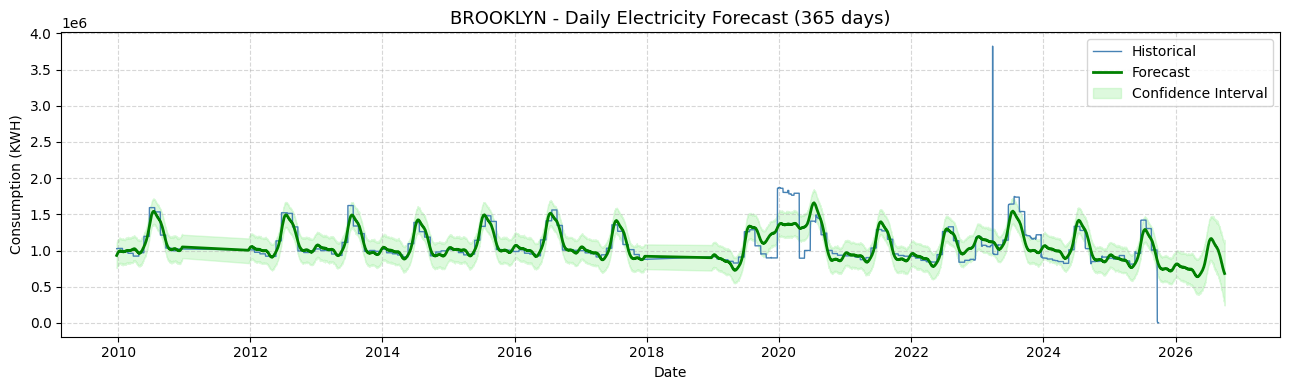


  MAE: 83,628.38   MAPE: 6994.71%   R²: 0.6697

── MANHATTAN ──

  Forecast for MANHATTAN (next 10 days shown):
  Date                Forecast (KWH)              Lower              Upper
  ----------------------------------------------------------------------
  2025-10-14              702,078.60         519,689.66         869,289.27
  2025-10-15              703,214.66         506,056.17         885,896.23
  2025-10-16              701,775.92         507,196.06         882,102.83
  2025-10-17              700,998.22         525,942.91         875,581.50
  2025-10-18              701,691.62         502,924.80         881,565.76
  2025-10-19              702,520.75         506,225.45         881,221.70
  2025-10-20              704,863.78         523,535.71         888,056.88
  2025-10-21              706,809.02         526,573.33         892,100.74
  2025-10-22              709,290.72         527,460.10         880,466.63
  2025-10-23              709,029.30         529,072.93         

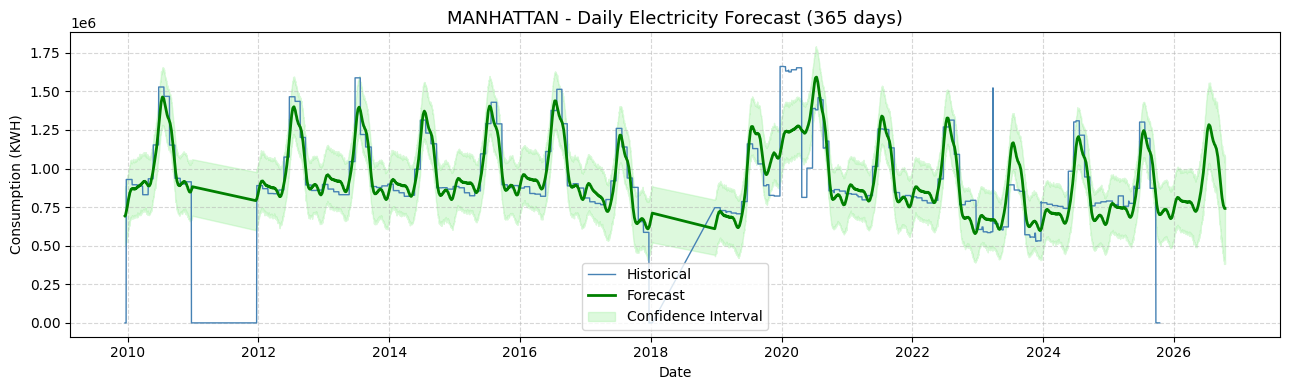


  MAE: 91,102.44   MAPE: 362779.98%   R²: 0.7000

── BRONX ──

  Forecast for BRONX (next 10 days shown):
  Date                Forecast (KWH)              Lower              Upper
  ----------------------------------------------------------------------
  2025-10-01              723,138.81         589,185.98         861,230.59
  2025-10-02              718,564.91         566,123.98         852,684.47
  2025-10-03              714,868.56         583,704.65         840,829.52
  2025-10-04              711,893.27         574,691.90         844,779.89
  2025-10-05              709,103.60         581,263.96         838,293.77
  2025-10-06              707,941.97         578,724.29         843,811.78
  2025-10-07              705,806.07         576,733.55         836,957.47
  2025-10-08              704,332.32         563,651.22         832,350.85
  2025-10-09              702,189.21         567,519.57         830,299.60
  2025-10-10              700,852.82         572,122.77         830,72

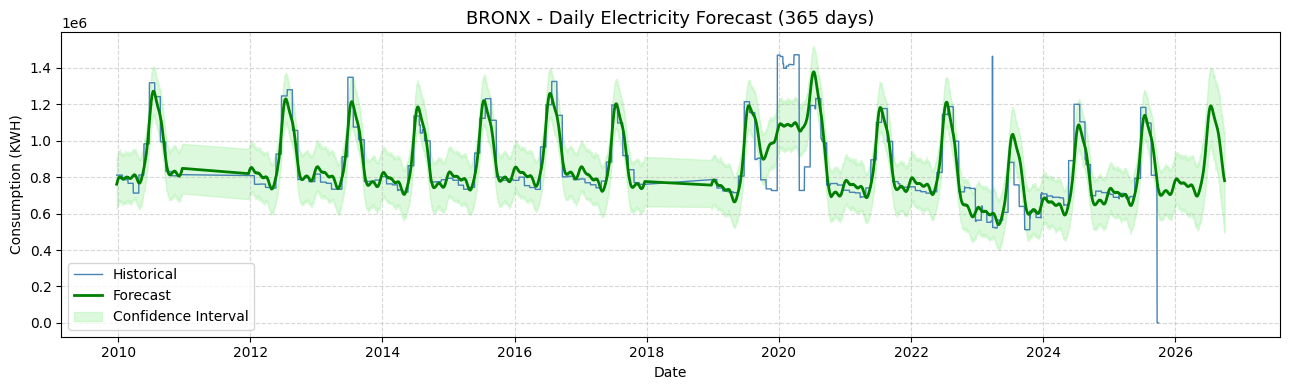


  MAE: 66,002.55   MAPE: 26506.05%   R²: 0.7367

── QUEENS ──

  Forecast for QUEENS (next 10 days shown):
  Date                Forecast (KWH)              Lower              Upper
  ----------------------------------------------------------------------
  2025-10-10              145,912.28          88,384.03         202,490.95
  2025-10-11              145,612.43          89,635.48         204,647.57
  2025-10-12              145,067.54          87,164.39         207,671.86
  2025-10-13              145,488.85          89,934.07         199,106.92
  2025-10-14              144,991.16          89,100.90         200,589.93
  2025-10-15              144,491.51          85,587.78         207,037.04
  2025-10-16              143,973.18          82,465.91         198,306.84
  2025-10-17              144,136.85          86,005.72         205,973.41
  2025-10-18              144,600.46          89,578.44         202,519.09
  2025-10-19              144,736.06          89,433.79         202,3

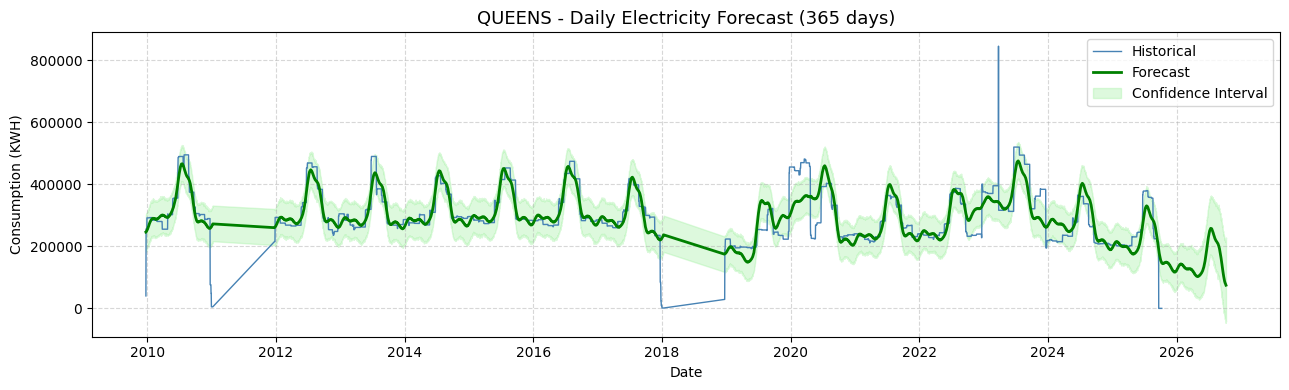


  MAE: 30,511.34   MAPE: 11657.27%   R²: 0.6958

── STATEN ISLAND ──

  Forecast for STATEN ISLAND (next 10 days shown):
  Date                Forecast (KWH)              Lower              Upper
  ----------------------------------------------------------------------
  2025-09-30               88,591.02          68,881.21         106,167.73
  2025-10-01               88,097.85          70,554.91         107,681.88
  2025-10-02               87,729.54          69,736.06         104,831.59
  2025-10-03               87,237.01          68,108.08         105,552.61
  2025-10-04               86,929.10          67,329.40         104,975.13
  2025-10-05               86,638.14          68,392.15         105,365.88
  2025-10-06               86,652.00          67,592.75         104,273.19
  2025-10-07               86,436.62          68,108.50         106,032.50
  2025-10-08               86,114.99          67,446.80         104,915.77
  2025-10-09               85,909.86          67,793.80

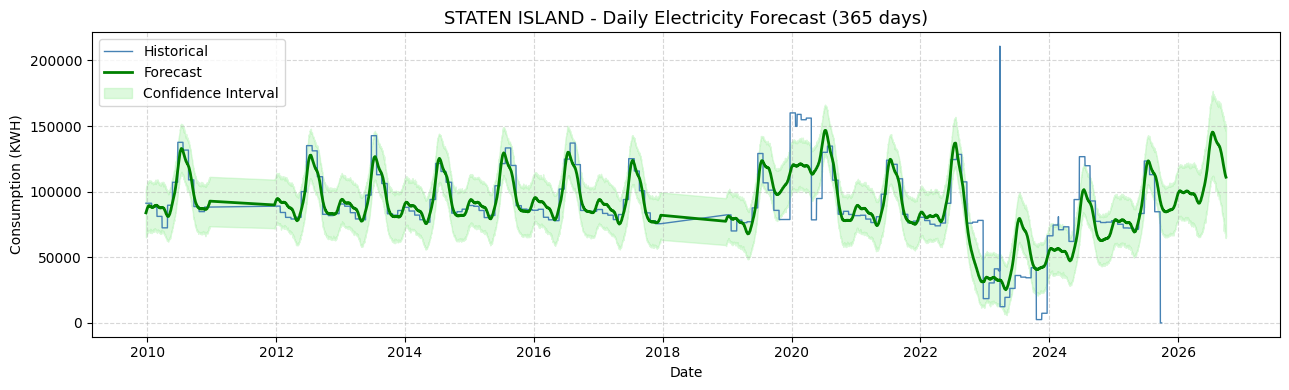


  MAE: 9,488.56   MAPE: 4832.62%   R²: 0.7167

✓ Borough forecasting complete.


In [13]:
print("=" * 60)
print("BOROUGH-LEVEL FORECASTING (Extra Credit)")
print("=" * 60)

# Build per-borough daily aggregates
borough_daily_data = {}

for borough in valid_boroughs:
    df_b = df_clean[df_clean["Borough"] == borough]
    expanded = []
    for _, row in df_b.iterrows():
        date_range = pd.date_range(
            start=row["Service Start Date"],
            end=row["Service End Date"] - pd.Timedelta(days=1)
        )
        for d in date_range:
            expanded.append({"ds": d, "y": row["daily_kwh"]})

    temp = pd.DataFrame(expanded)
    temp = temp.groupby("ds").agg({"y": "sum"}).reset_index()
    borough_daily_data[borough] = temp
    print(f"  {borough}: {temp.shape[0]} daily records")

print("\nTraining & forecasting per borough (365 days)...")
borough_results = []

for borough in valid_boroughs:
    print(f"\n── {borough} ──")
    data = borough_daily_data[borough]

    model = Prophet(
        growth="linear",
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        n_changepoints=25,
        changepoint_prior_scale=0.3
    )
    model.add_seasonality(name='yearly', period=365.25, fourier_order=8)
    model.add_seasonality(name='weekly', period=7, fourier_order=3)
    model.fit(data)

    future = model.make_future_dataframe(periods=365, freq="D")
    forecast = model.predict(future)

    # Print tabular forecast (last 10 future dates)
    future_only = forecast[forecast["ds"] > data["ds"].max()]
    print(f"\n  Forecast for {borough} (next 10 days shown):")
    print(f"  {'Date':<15} {'Forecast (KWH)':>18} {'Lower':>18} {'Upper':>18}")
    print(f"  {'-'*70}")
    for _, r in future_only.head(10).iterrows():
        print(f"  {str(r['ds'].date()):<15} {r['yhat']:>18,.2f} "
              f"{r['yhat_lower']:>18,.2f} {r['yhat_upper']:>18,.2f}")

    # Plot
    plt.figure(figsize=(13, 4))
    plt.plot(data["ds"], data["y"], label="Historical", color="steelblue", linewidth=1)
    plt.plot(forecast["ds"], forecast["yhat"], label="Forecast", color="green", linewidth=2)
    plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                     color="lightgreen", alpha=0.3, label="Confidence Interval")
    plt.title(f"{borough} - Daily Electricity Forecast (365 days)", fontsize=13)
    plt.xlabel("Date")
    plt.ylabel("Consumption (KWH)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Evaluate
    merged = data.merge(forecast[["ds", "yhat"]], on="ds", how="inner").dropna()
    mae  = mean_absolute_error(merged["y"], merged["yhat"])
    mask = merged["y"] > 0
    mape = mean_absolute_percentage_error(merged["y"][mask], merged["yhat"][mask]) * 100
    r2   = r2_score(merged["y"], merged["yhat"])
    print(f"\n  MAE: {mae:,.2f}   MAPE: {mape:.2f}%   R²: {r2:.4f}")
    borough_results.append({"Borough": borough, "MAE": mae, "MAPE%": mape, "R2": r2})

print("\n✓ Borough forecasting complete.")

In [14]:
print("=" * 60)
print("FINAL MODEL EVALUATION SUMMARY")
print("=" * 60)

import pandas as pd

# ── Compile all results ───────────────────────────────────────
all_results = [
    # Daily - 3 growth types
    {"Dataset": "Daily",   "Model": "Linear Growth",              "MAE": 289490.86, "MAPE%": "N/A (zero vals)", "R2": 0.6311},
    {"Dataset": "Daily",   "Model": "Logistic Growth",            "MAE": 308038.33, "MAPE%": "N/A (zero vals)", "R2": 0.5368},
    {"Dataset": "Daily",   "Model": "Flat Growth",                "MAE": 331815.77, "MAPE%": "N/A (zero vals)", "R2": 0.4767},
    # Monthly - 3 growth types
    {"Dataset": "Monthly", "Model": "Linear Growth",              "MAE": 313946.23, "MAPE%": "N/A (zero vals)", "R2": 0.4855},
    {"Dataset": "Monthly", "Model": "Logistic Growth",            "MAE": 314493.74, "MAPE%": "N/A (zero vals)", "R2": 0.4786},
    {"Dataset": "Monthly", "Model": "Flat Growth",                "MAE": 343453.60, "MAPE%": "N/A (zero vals)", "R2": 0.4595},
    # Yearly - 3 growth types
    {"Dataset": "Yearly",  "Model": "Linear Growth",              "MAE": 592484.34, "MAPE%": "31.93%",          "R2": 0.0398},
    {"Dataset": "Yearly",  "Model": "Logistic Growth",            "MAE": 602763.45, "MAPE%": "33.25%",          "R2": -0.0320},
    {"Dataset": "Yearly",  "Model": "Flat Growth",                "MAE": 577090.35, "MAPE%": "32.33%",          "R2": -0.0000},
    # Tuned models
    {"Dataset": "Daily",   "Model": "Custom Seasonality (tuned)", "MAE": 254120.18, "MAPE%": "N/A (zero vals)", "R2": 0.7222},
    {"Dataset": "Daily",   "Model": "Alt Seasonality (tuned)",    "MAE": 310680.03, "MAPE%": "N/A (zero vals)", "R2": 0.5331},
    {"Dataset": "Monthly", "Model": "Custom Seasonality (tuned)", "MAE": 322904.87, "MAPE%": "N/A (zero vals)", "R2": 0.5172},
    {"Dataset": "Yearly",  "Model": "Changepoint Tuned",          "MAE": 592473.62, "MAPE%": "31.93%",          "R2": 0.0399},
]

# ── Borough results ───────────────────────────────────────────
for b in borough_results:
    all_results.append({
        "Dataset": f"Daily ({b['Borough']})",
        "Model":   "Linear + Custom Seasonality",
        "MAE":     round(b["MAE"], 2),
        "MAPE%":   f"{b['MAPE%']:.2f}%",
        "R2":      round(b["R2"], 4)
    })

summary_df = pd.DataFrame(all_results)
summary_df["R2"] = summary_df["R2"].apply(lambda x: f"{x:.4f}")
summary_df["MAE"] = summary_df["MAE"].apply(lambda x: f"{x:,.2f}" if isinstance(x, float) else x)

print(f"\n{'Dataset':<22} {'Model':<30} {'MAE':>16} {'MAPE':>18} {'R²':>8}")
print("-" * 96)
for _, row in summary_df.iterrows():
    print(f"{row['Dataset']:<22} {row['Model']:<30} {row['MAE']:>16} {row['MAPE%']:>18} {row['R2']:>8}")

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print("""
Daily Data:
  • Best model: Custom Seasonality (fourier=10, n_changepoints=30)
    → R²=0.7222, MAE=254,120 KWH
  • Linear growth outperforms logistic and flat
  • High MAPE due to near-zero values in early 2010 data

Monthly Data:
  • Linear growth performs best (R²=0.4855)
  • Custom seasonality improved R² to 0.5172
  • Seasonal peaks visible every summer (July/August)

Yearly Data:
  • Low R² across all models (max 0.04) — expected
    with only 17 data points and high inter-year variance
  • Linear growth gives the most reasonable long-term trend

Borough-Level (Extra Credit):
  • Bronx has the best individual R² (0.7367)
  • Staten Island has the lowest MAE (9,488 KWH) — smallest borough
  • Brooklyn has the highest consumption overall
  • All 5 boroughs show clear summer consumption peaks
""")

print("✓ Project complete.")

FINAL MODEL EVALUATION SUMMARY

Dataset                Model                                       MAE               MAPE       R²
------------------------------------------------------------------------------------------------
Daily                  Linear Growth                        289,490.86    N/A (zero vals)   0.6311
Daily                  Logistic Growth                      308,038.33    N/A (zero vals)   0.5368
Daily                  Flat Growth                          331,815.77    N/A (zero vals)   0.4767
Monthly                Linear Growth                        313,946.23    N/A (zero vals)   0.4855
Monthly                Logistic Growth                      314,493.74    N/A (zero vals)   0.4786
Monthly                Flat Growth                          343,453.60    N/A (zero vals)   0.4595
Yearly                 Linear Growth                        592,484.34             31.93%   0.0398
Yearly                 Logistic Growth                      602,763.45         